# Proof of concept del fit multi-pseudo-Voigt

In [1]:
import numpy as np

# Spettri
s = np.load('../data/10k/X_spectra_10k.npy')#, mmap_mode='r')
# Corrispondenti campi magnetici
B = np.load('../data/10k/Y_B_field_10k.npy')
# Asse x (frequenze)
f = np.arange(2500, 3300) 
x_axis = range(2500, 3300)

N_spettri, N_punti = s.shape[0], s.shape[1]

In [2]:
k_list = [0, 500, 1_500, 2_500, 3_500, 5_000, 7_000, 9_000, -1]

In [3]:
# normalizzo singolarmente ogni spettro al suo massimo, utile per impostare 
# threshold per i picchi con soglie fisse
for i in range(N_spettri):
    amp = np.max(np.abs(s[i]))
    s[i] = s[i] / amp

In [4]:
# ordino gli spettri in base al campo magnetico in ordine crescente
s = s[np.argsort(B)]
B = np.sort(B)

In [5]:
from scipy.signal import find_peaks

def trova_dip_scipy(frequenze, spettro, soglia=-0.05):
    """
    Trova i dip (minimi) in uno spettro usando scipy.
    frequenze: asse x (es. array da 750 elementi)
    spettro: asse y (es. array da 750 elementi)
    soglia: valore sotto il quale considerare valido il dip
    """
    # find_peaks cerca i massimi, quindi invertiamo lo spettro
    # La soglia diventa positiva per la ricerca dei massimi
    indici_picchi, info = find_peaks(
        -spettro, 
        height=-soglia,
        #prominence=0.000001,  # Prominenza minima del picco
        width=1 # Utile perché è la stima del gamma della lorentziana
    )
    
    # Estraiamo le posizioni in frequenza
    posizioni = frequenze[indici_picchi]
    
    return posizioni, info

In [6]:
# Liste per salvare i risultati di tutti gli spettri
num_picchi_totale = np.zeros(N_spettri, dtype=int)
posizioni_totali = []
info_totale = [] 

for i in range(N_spettri):
    spettro_corrente = s[i]
    pos, info = trova_dip_scipy(f, spettro_corrente, soglia=-0.05)
    
    num_picchi_totale[i] = len(pos)
    posizioni_totali.append(pos)
    info_totale.append(info)

In [7]:
for idx, n in enumerate(num_picchi_totale):
    #if n % 2 != 0:
    if n>8:
        print(idx, n)

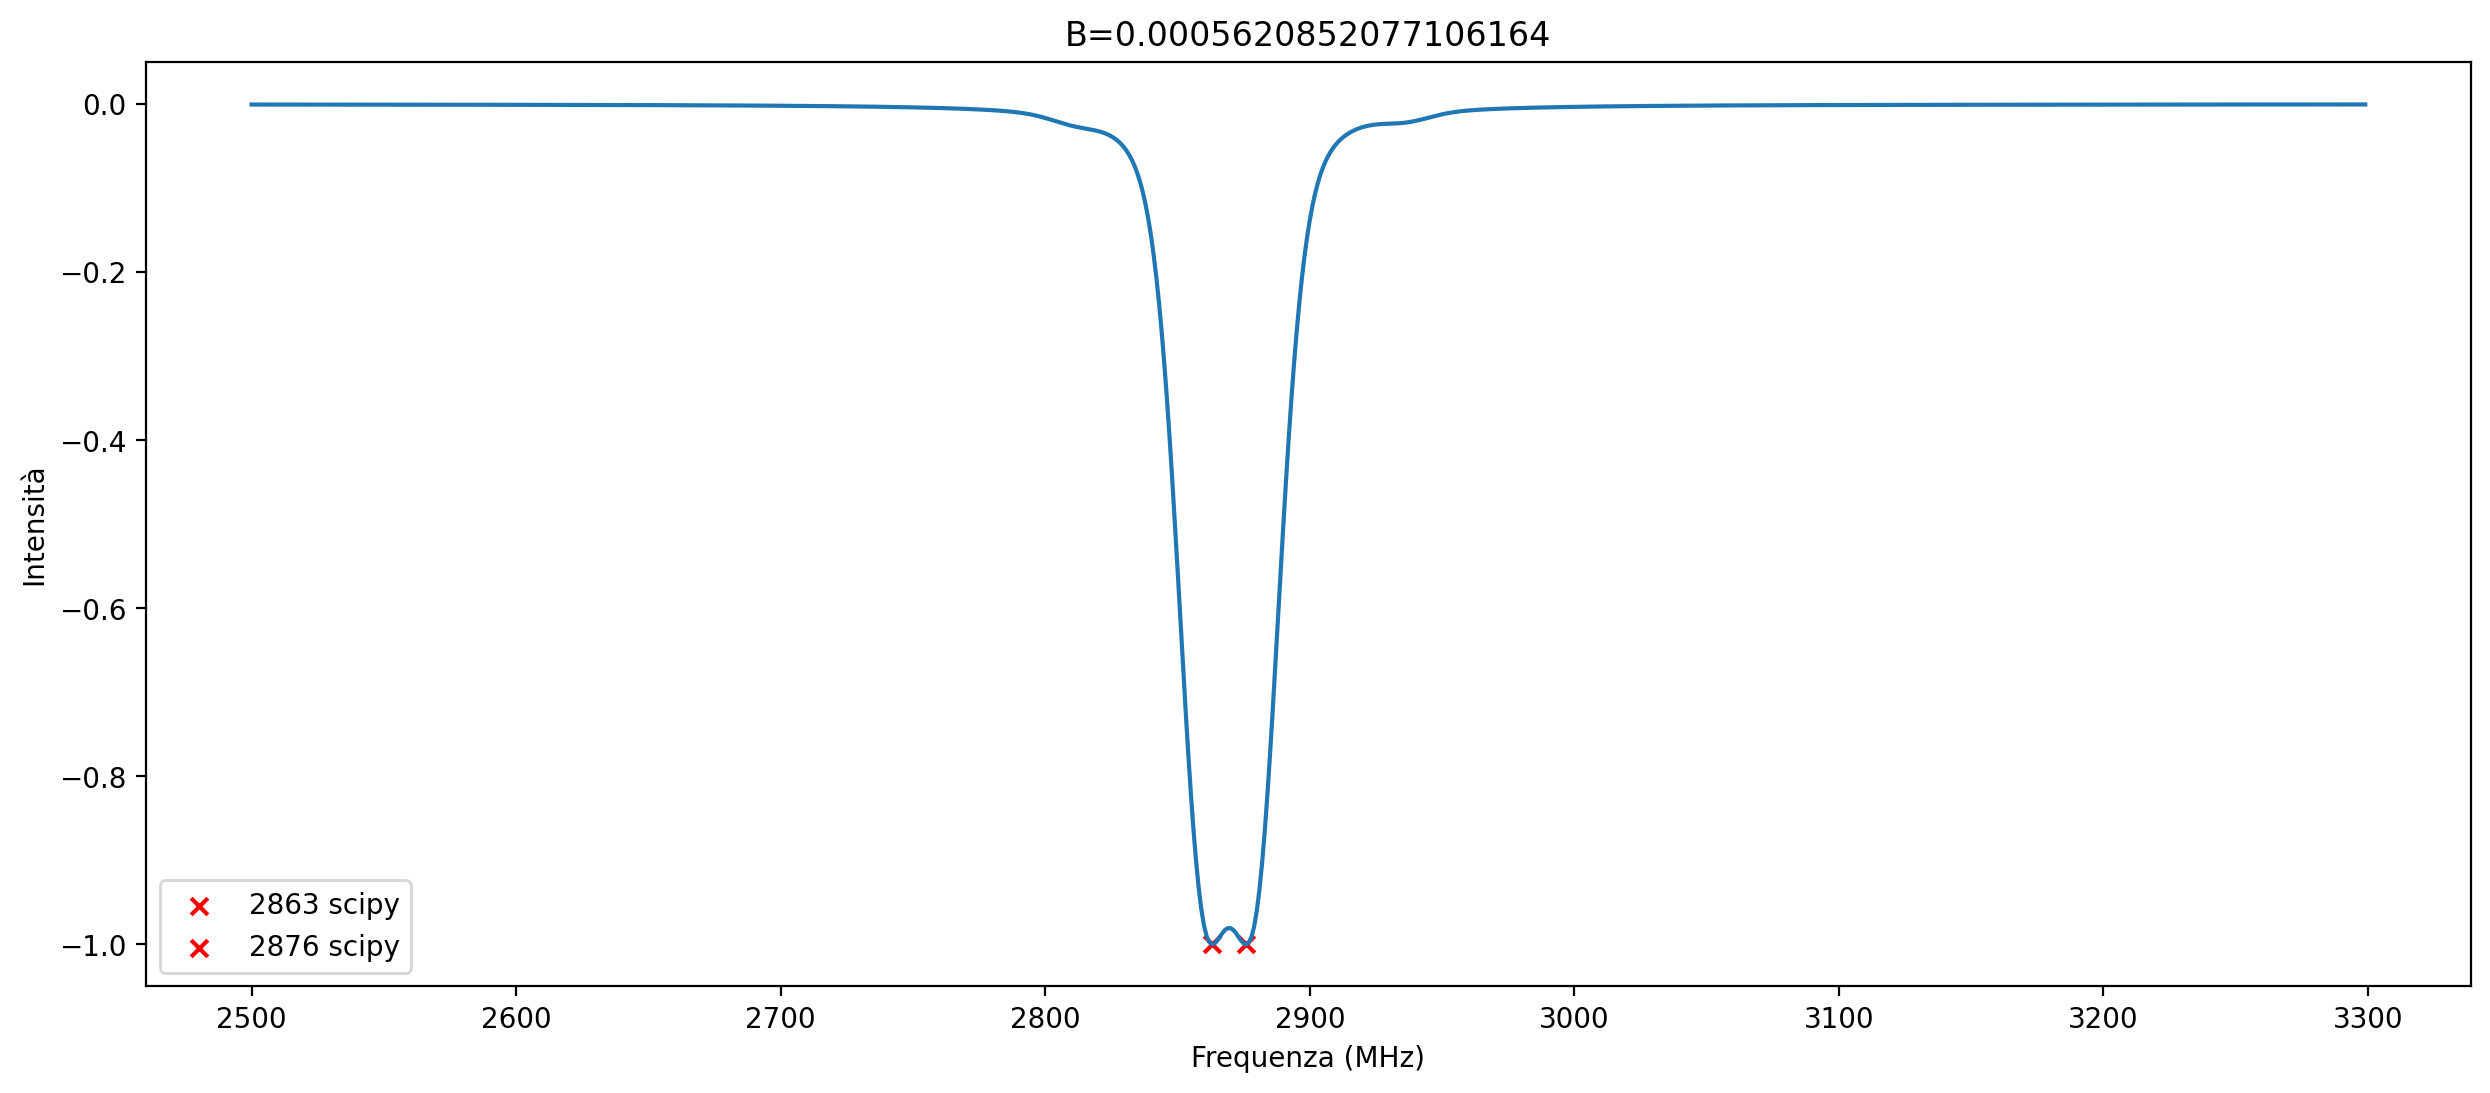

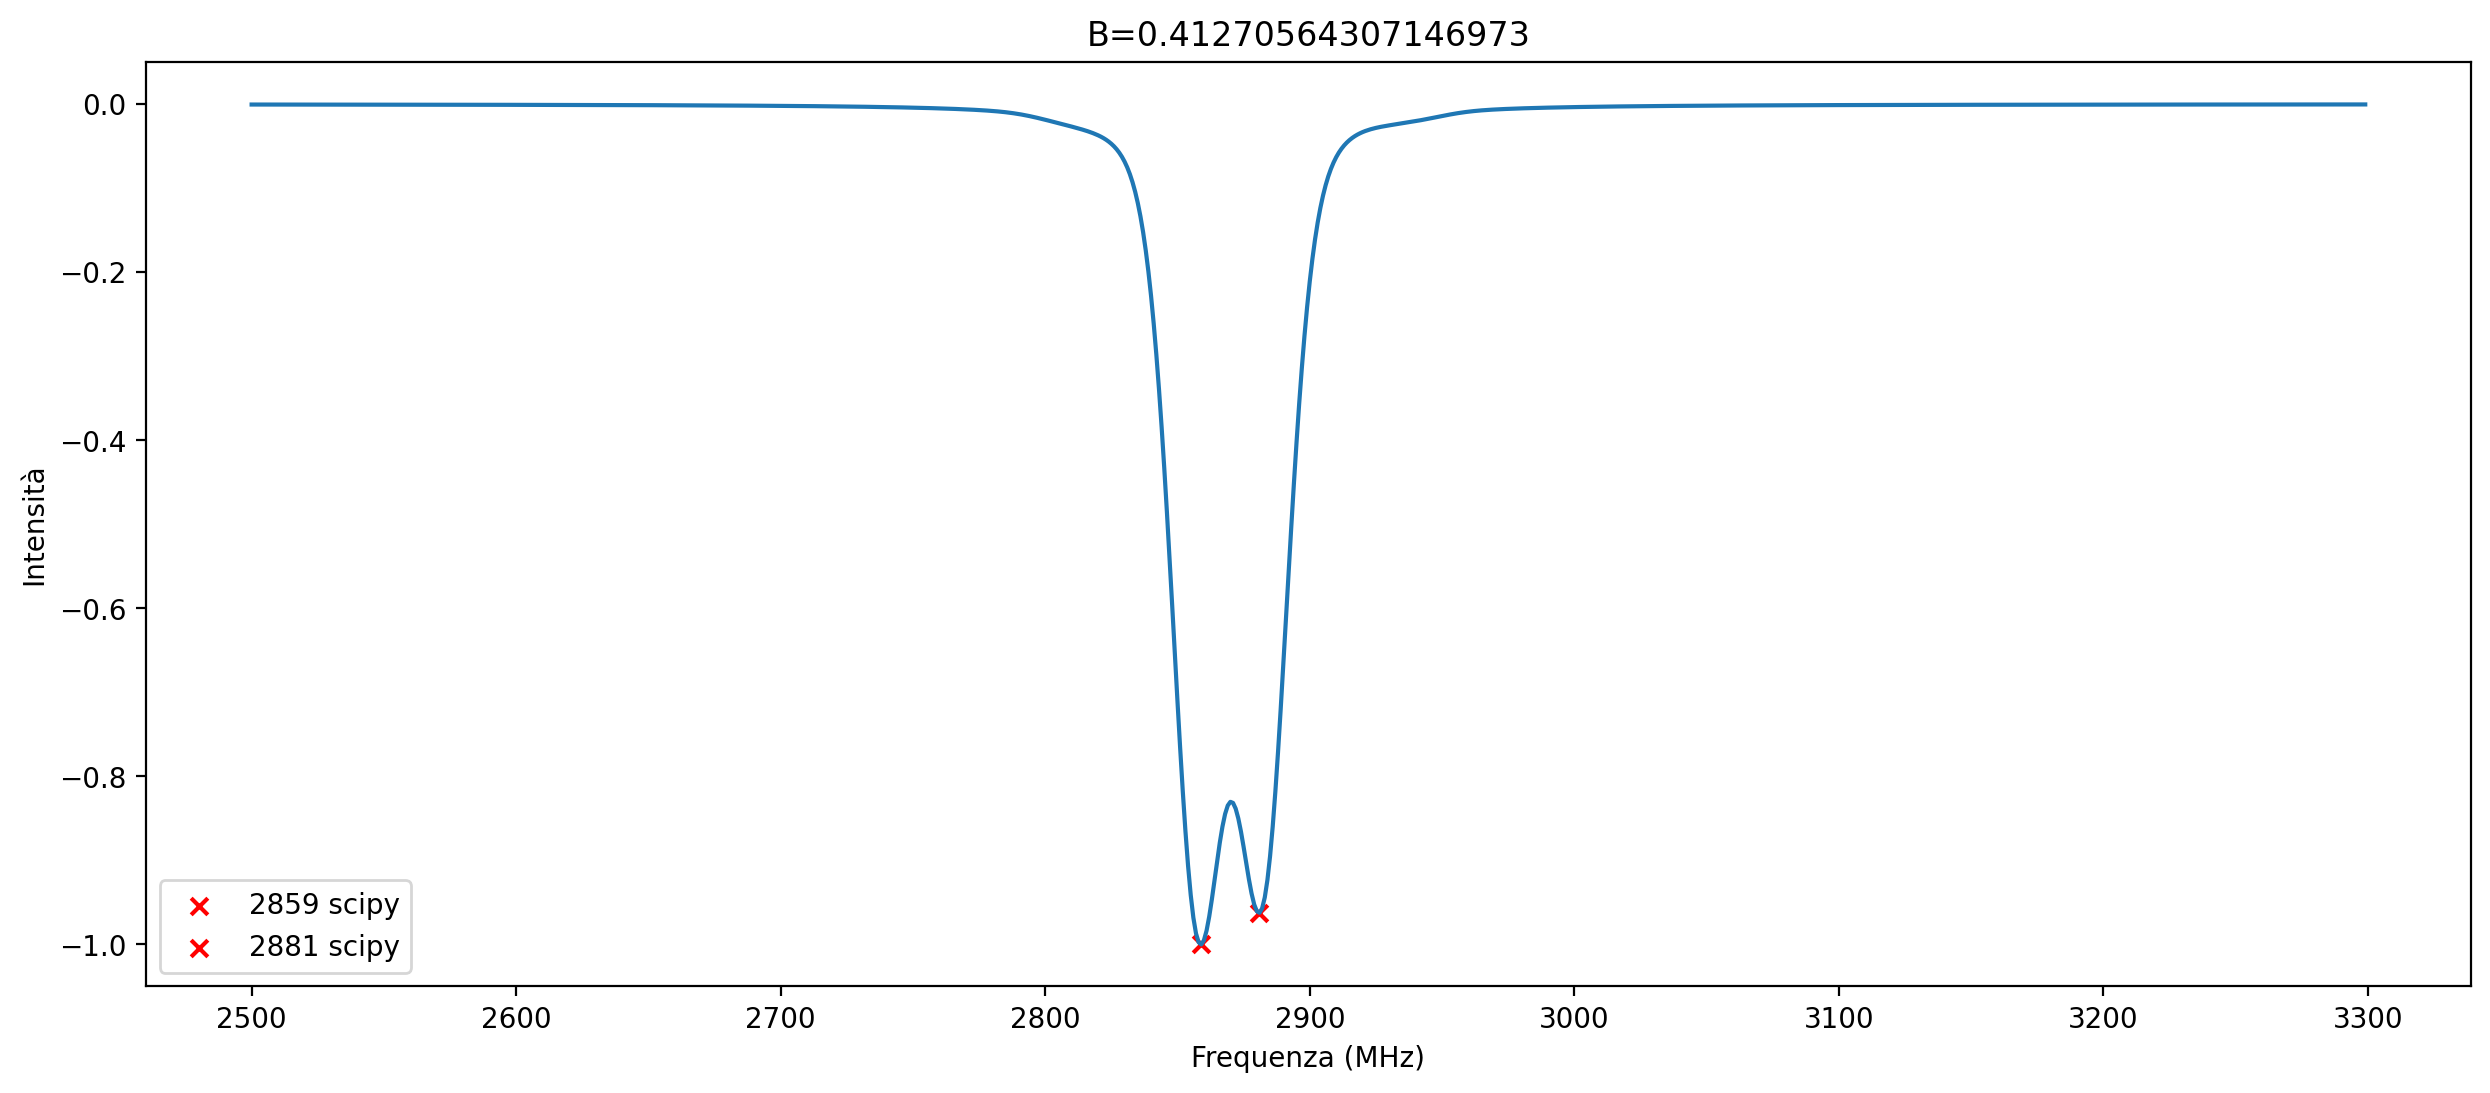

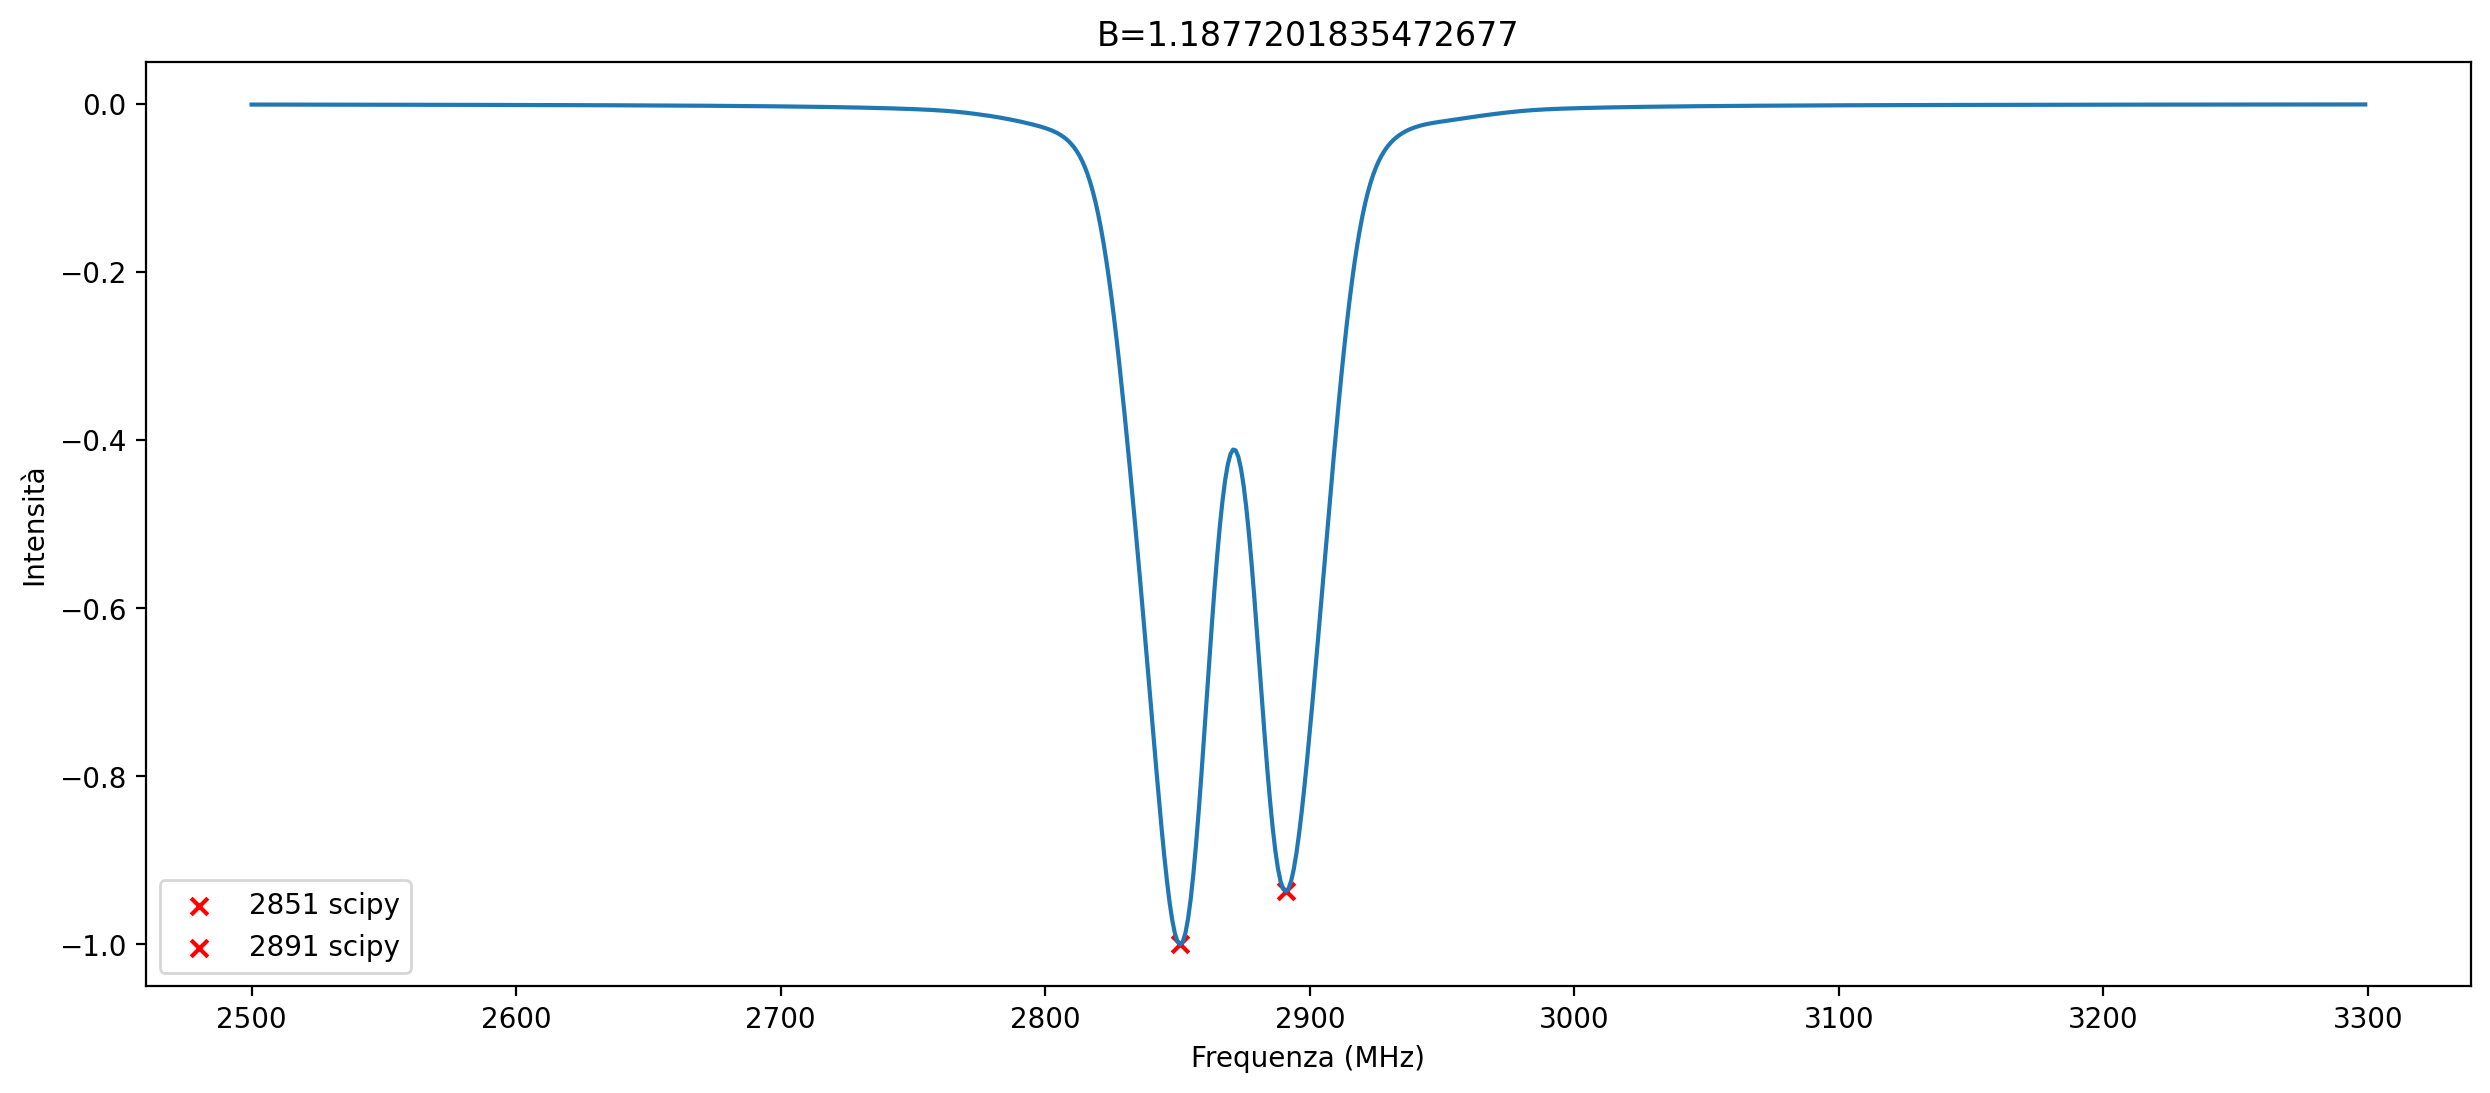

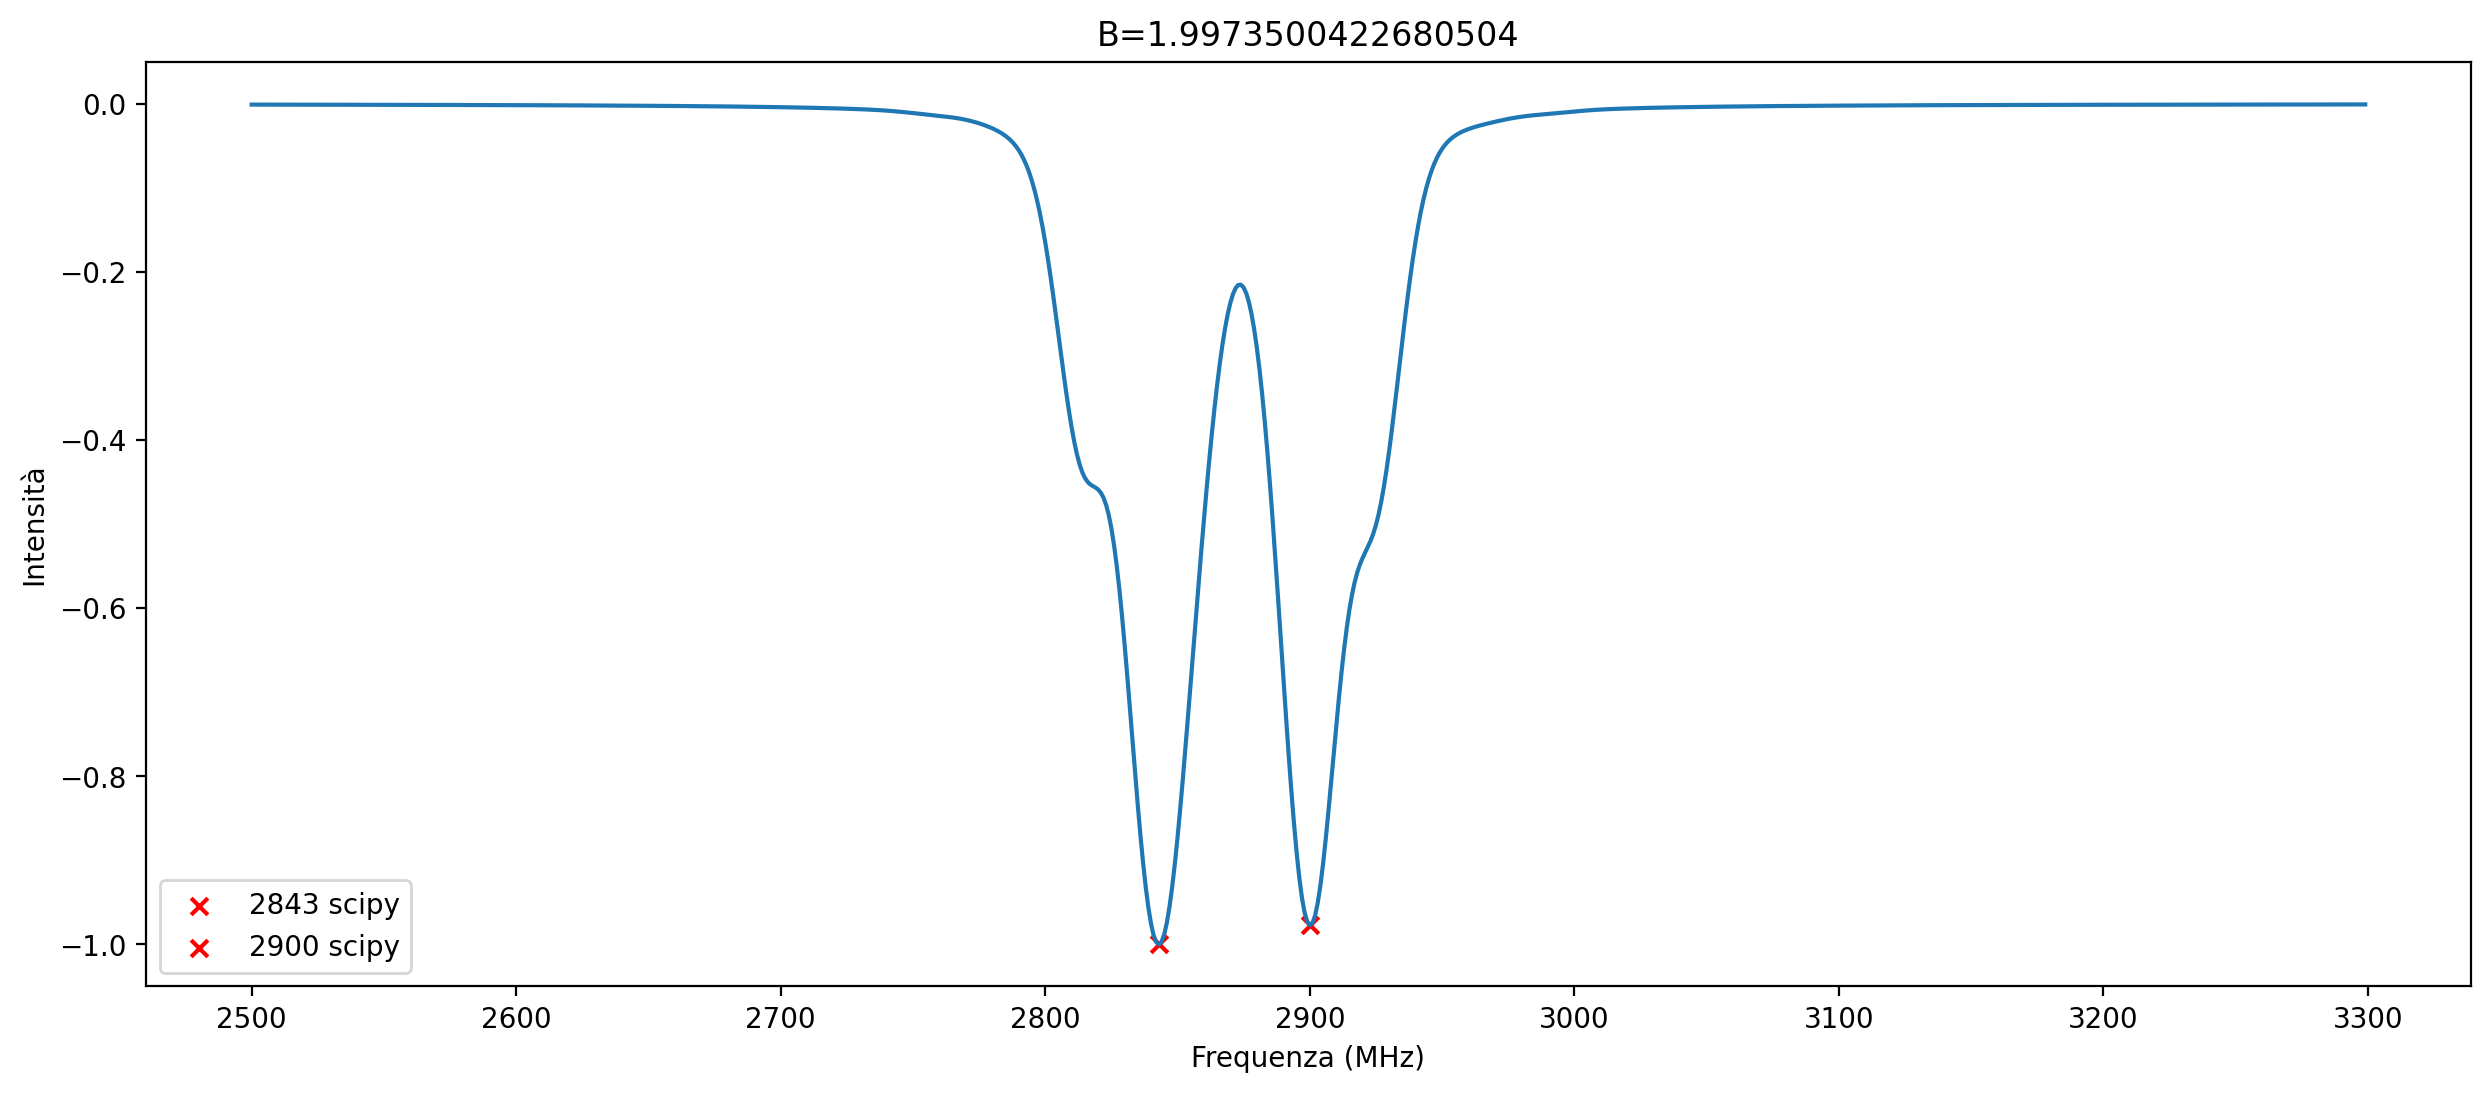

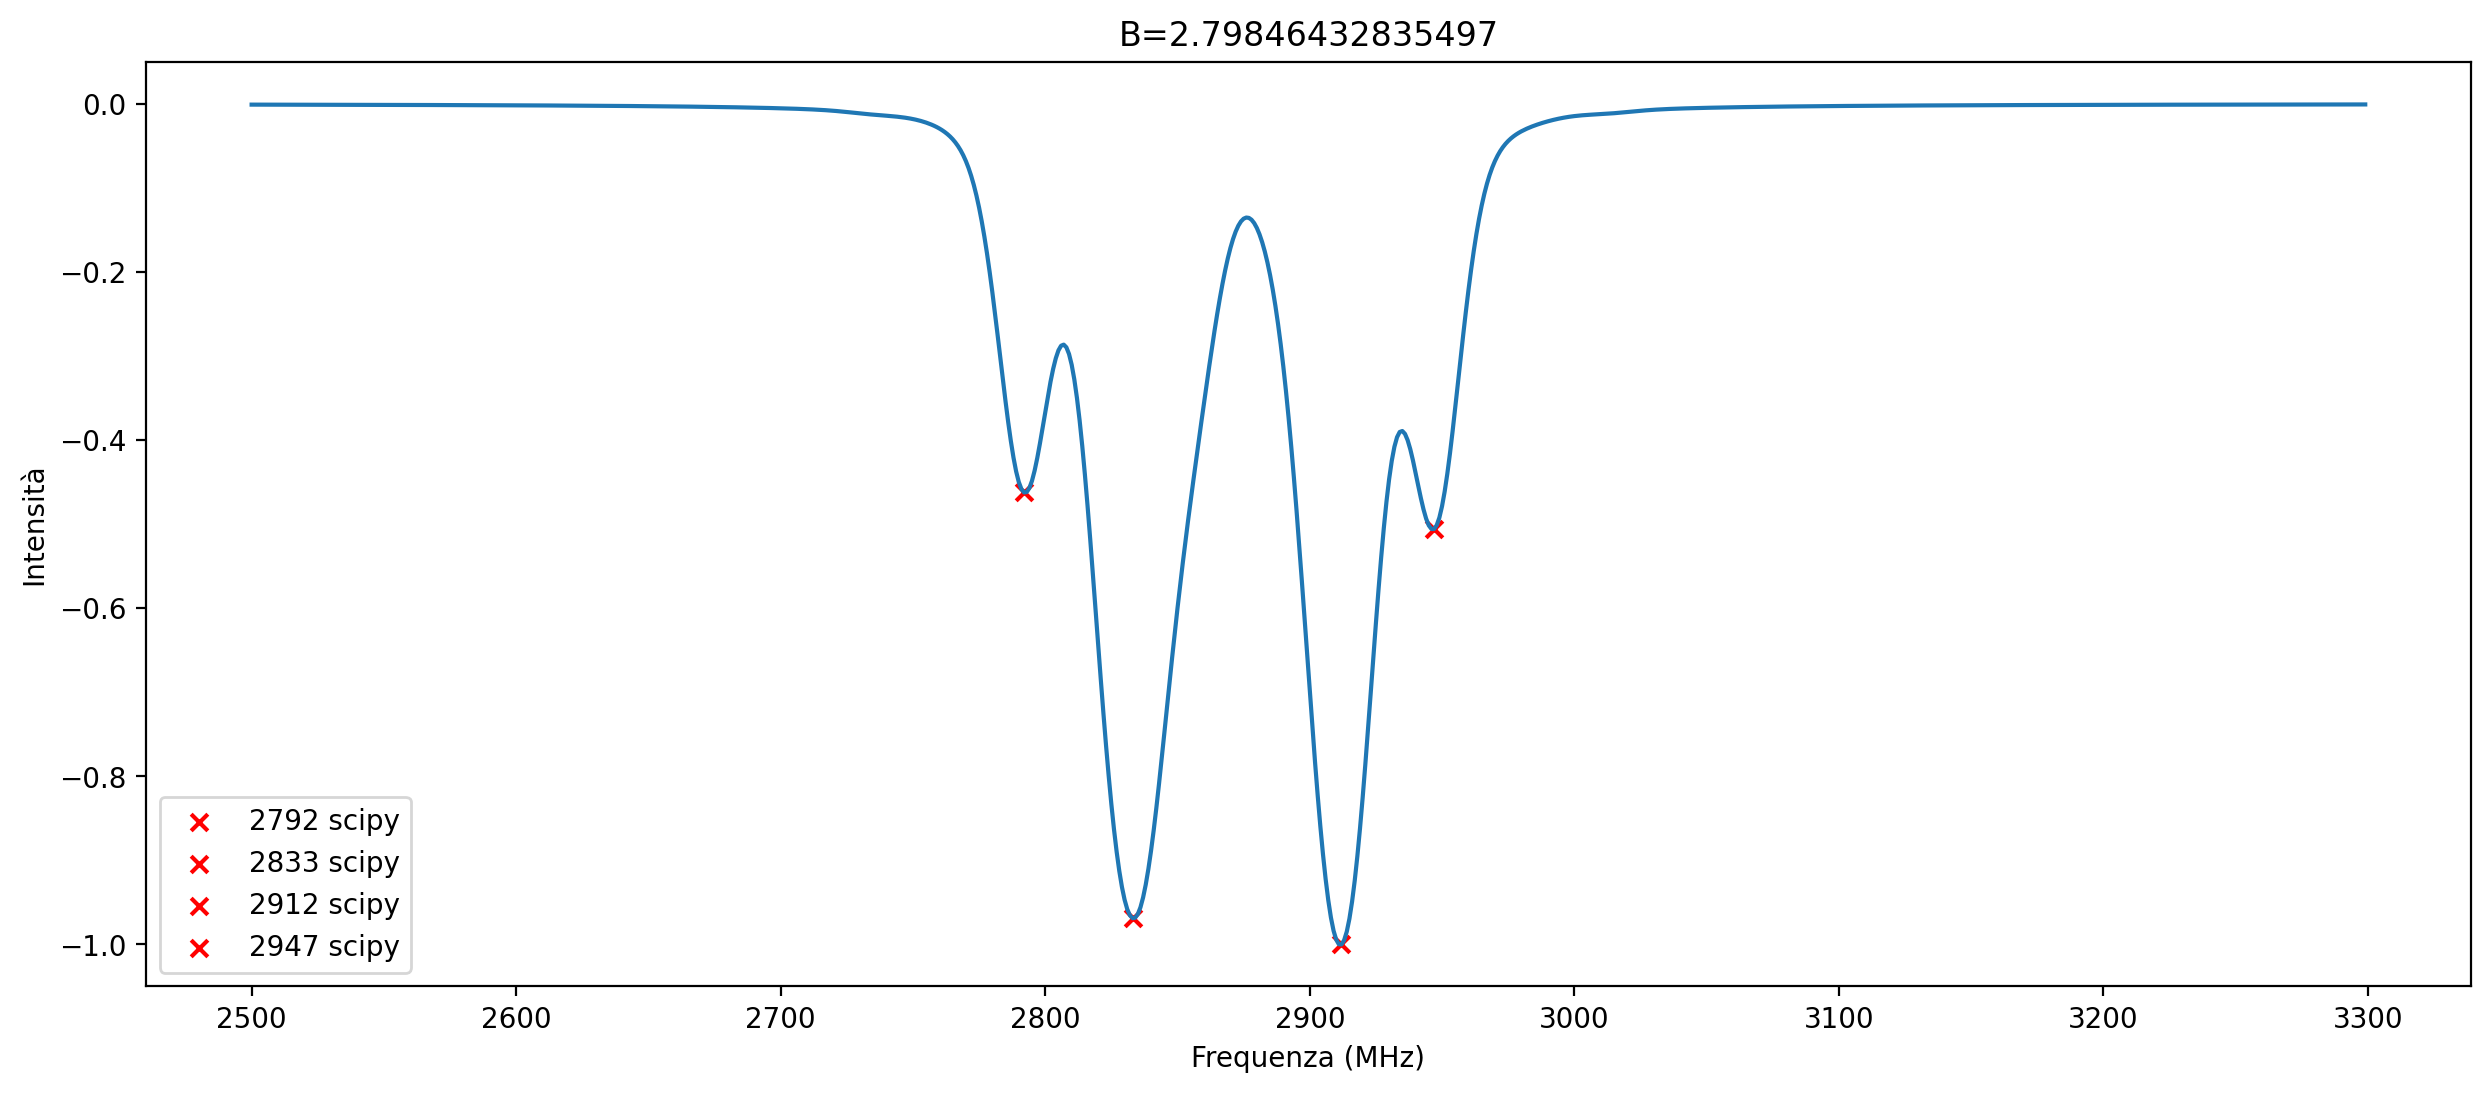

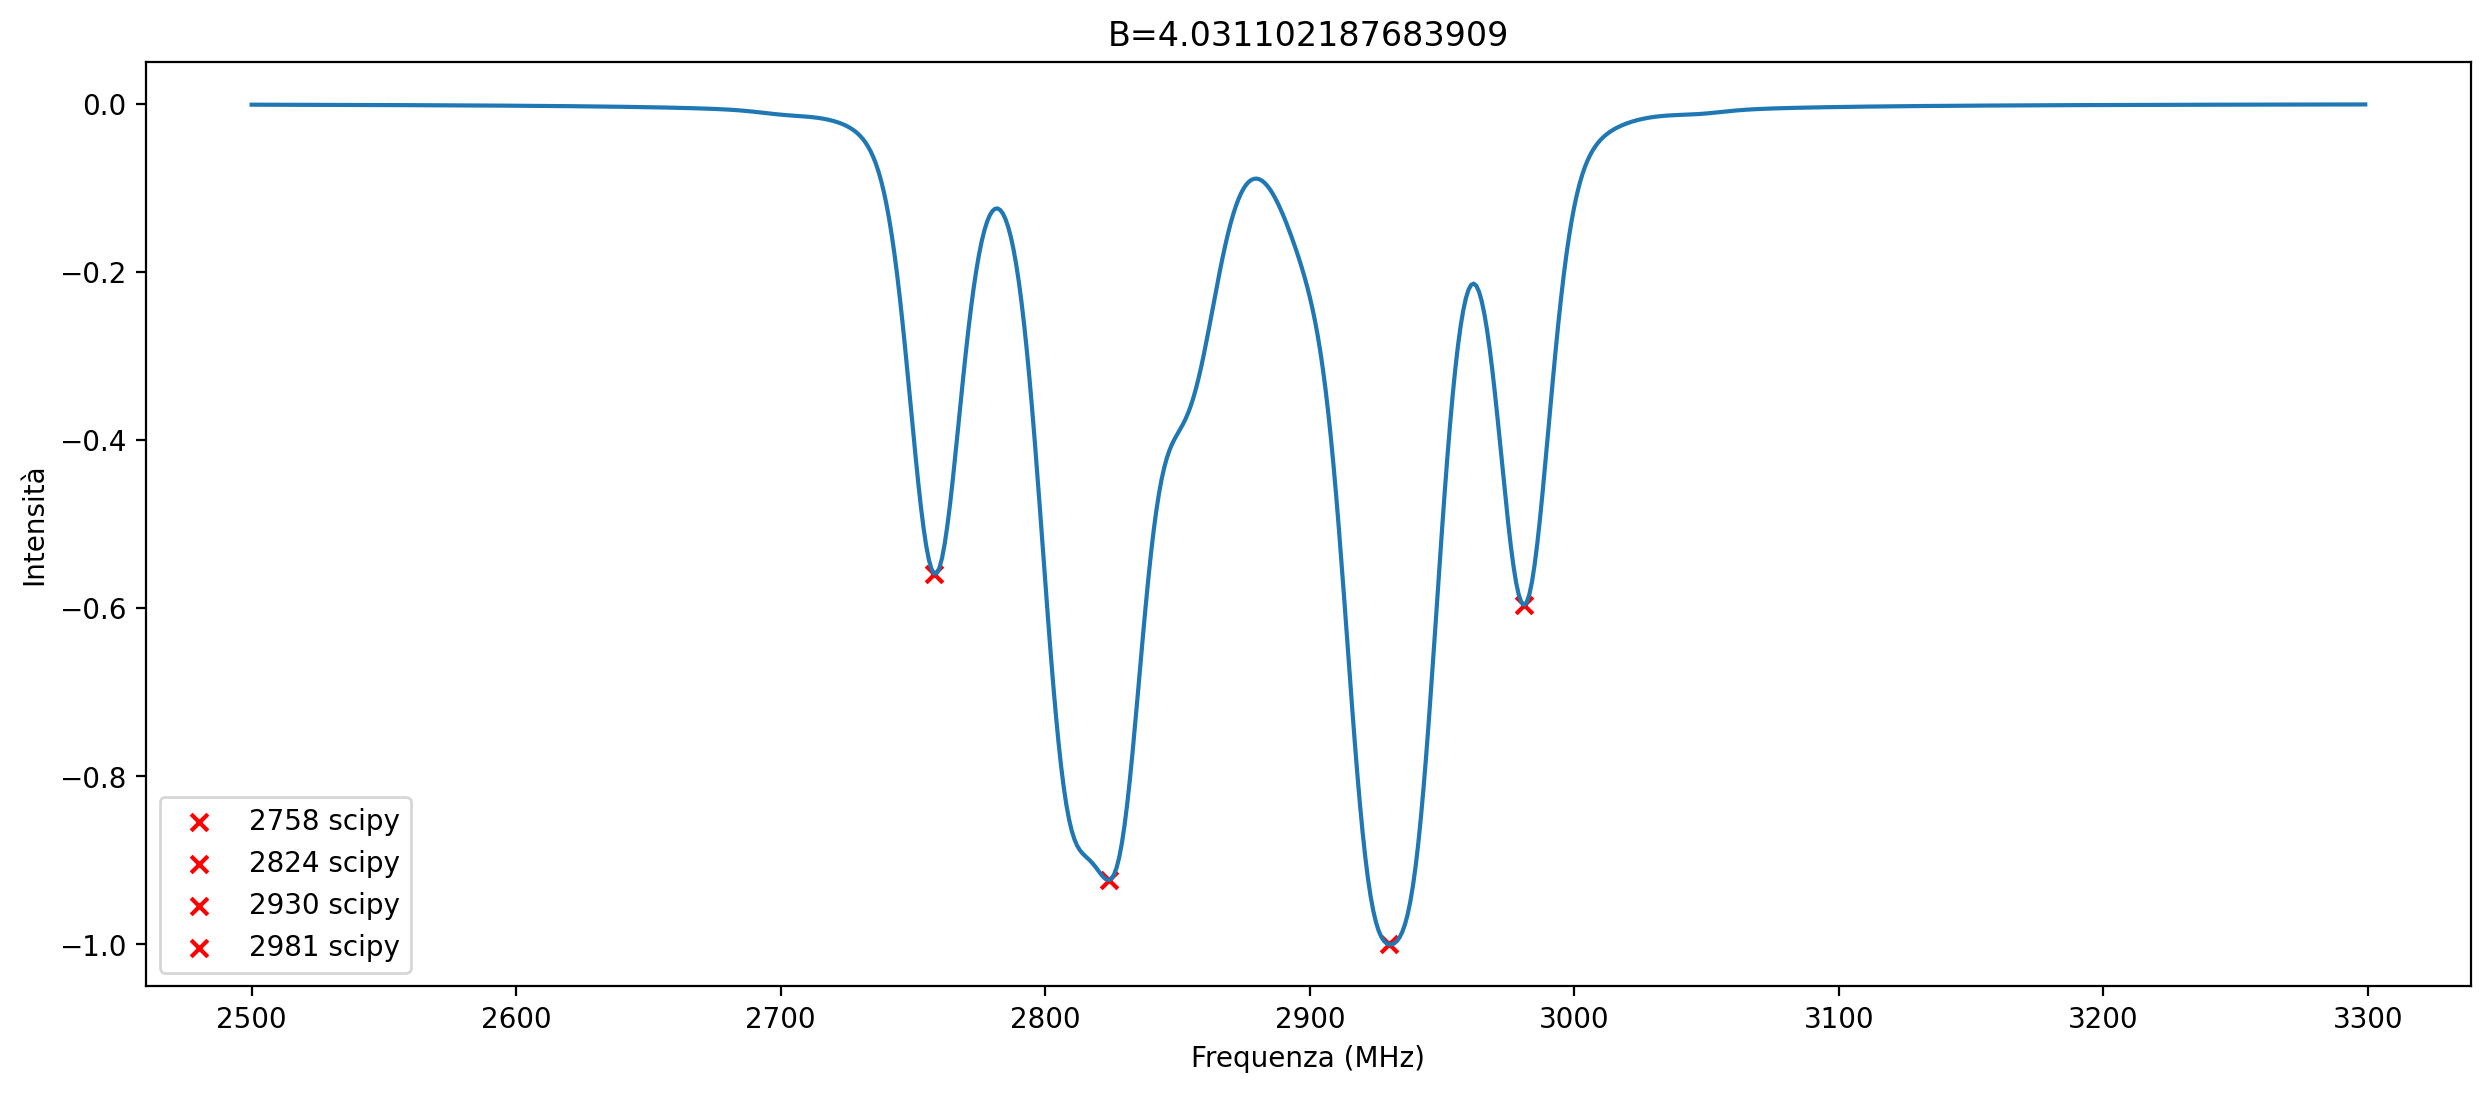

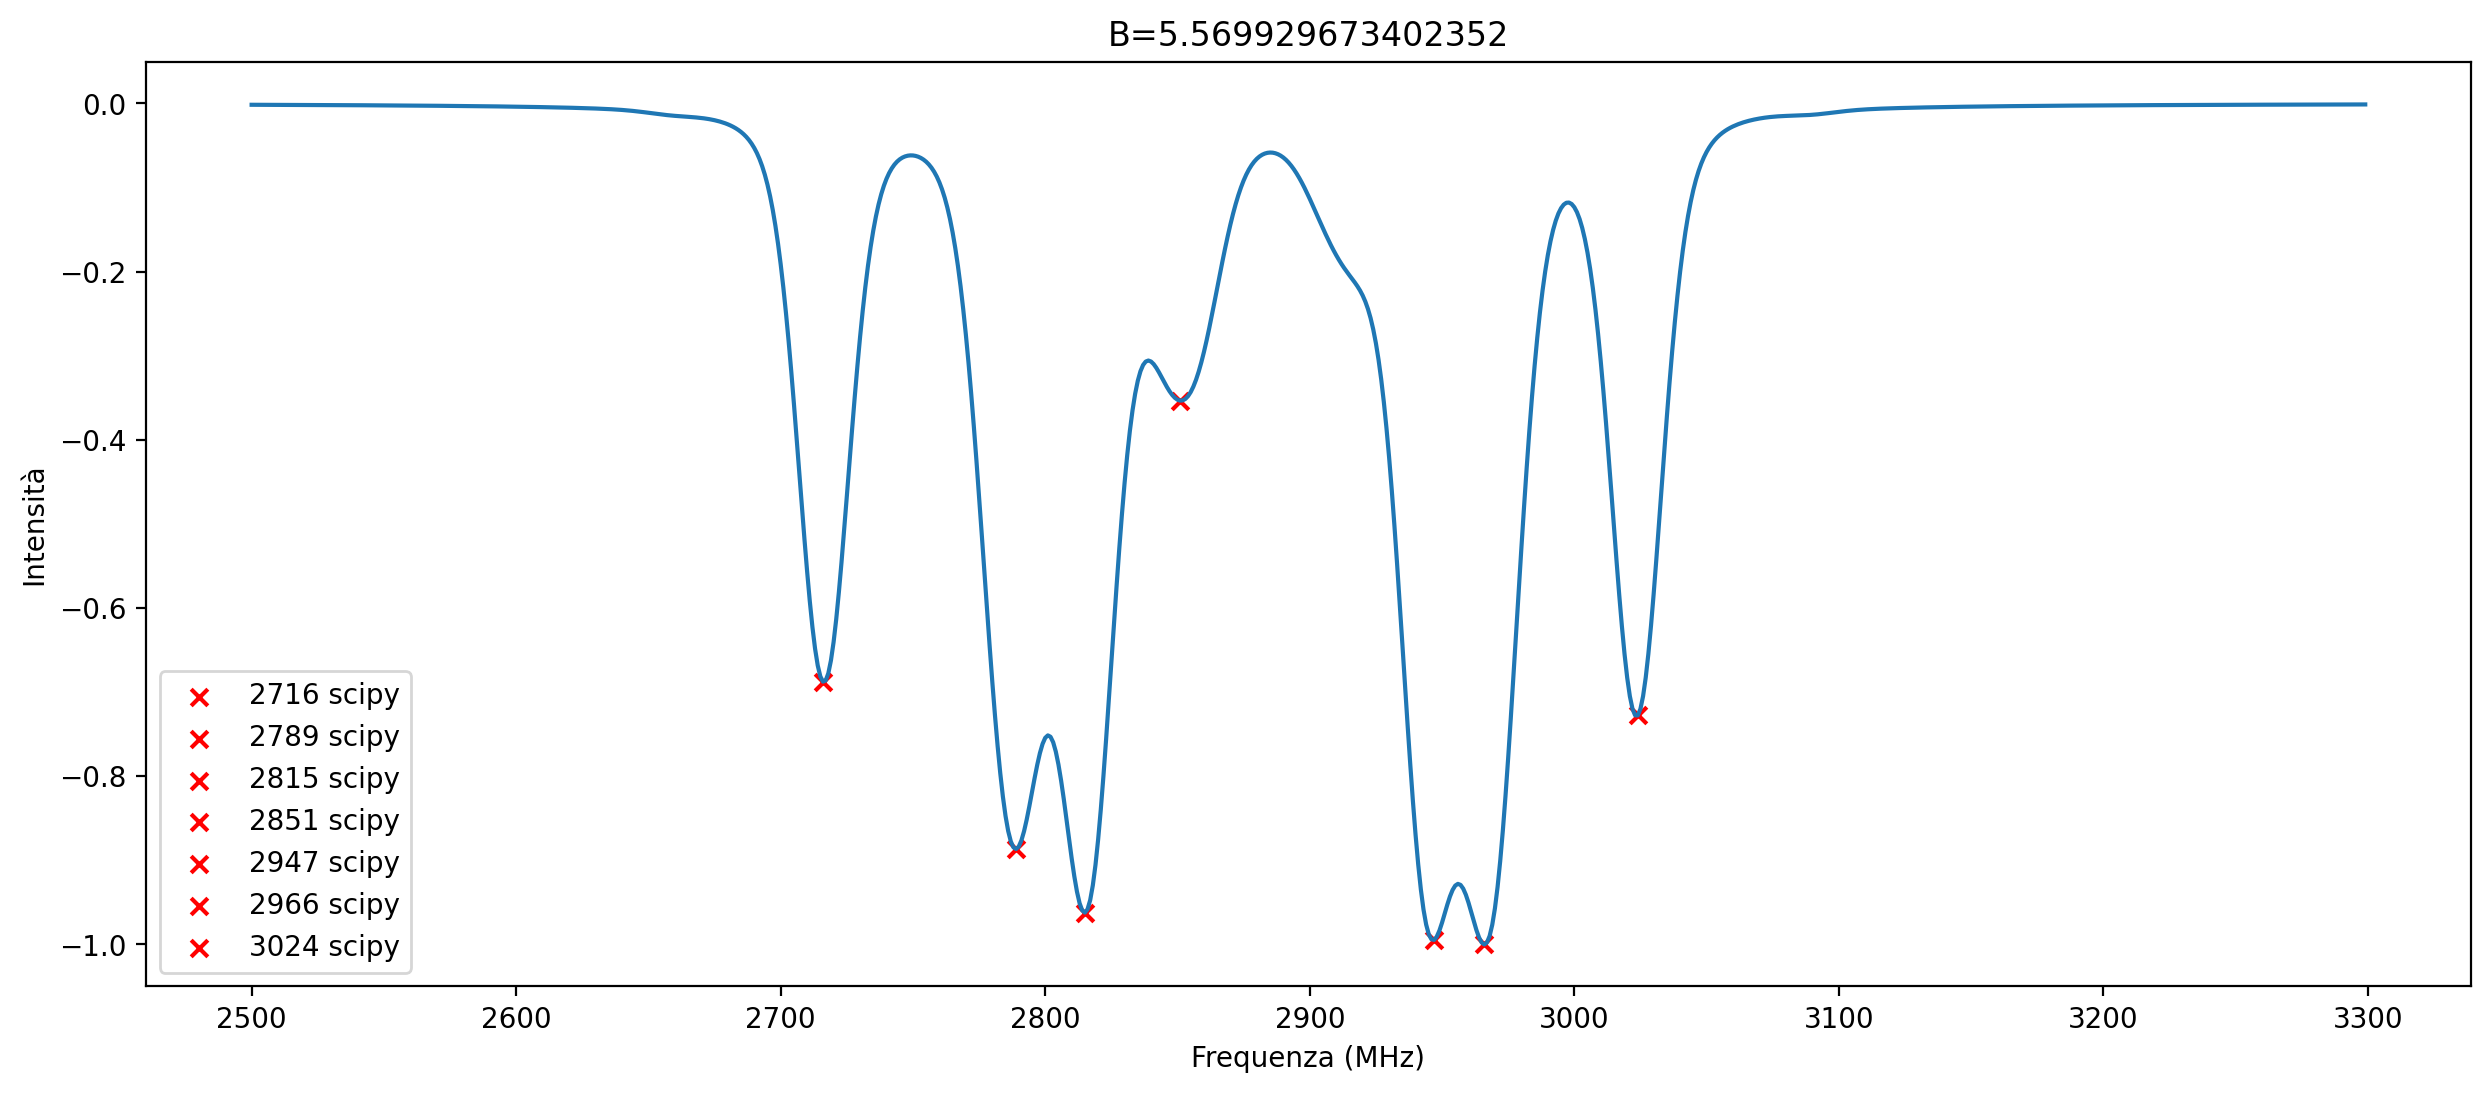

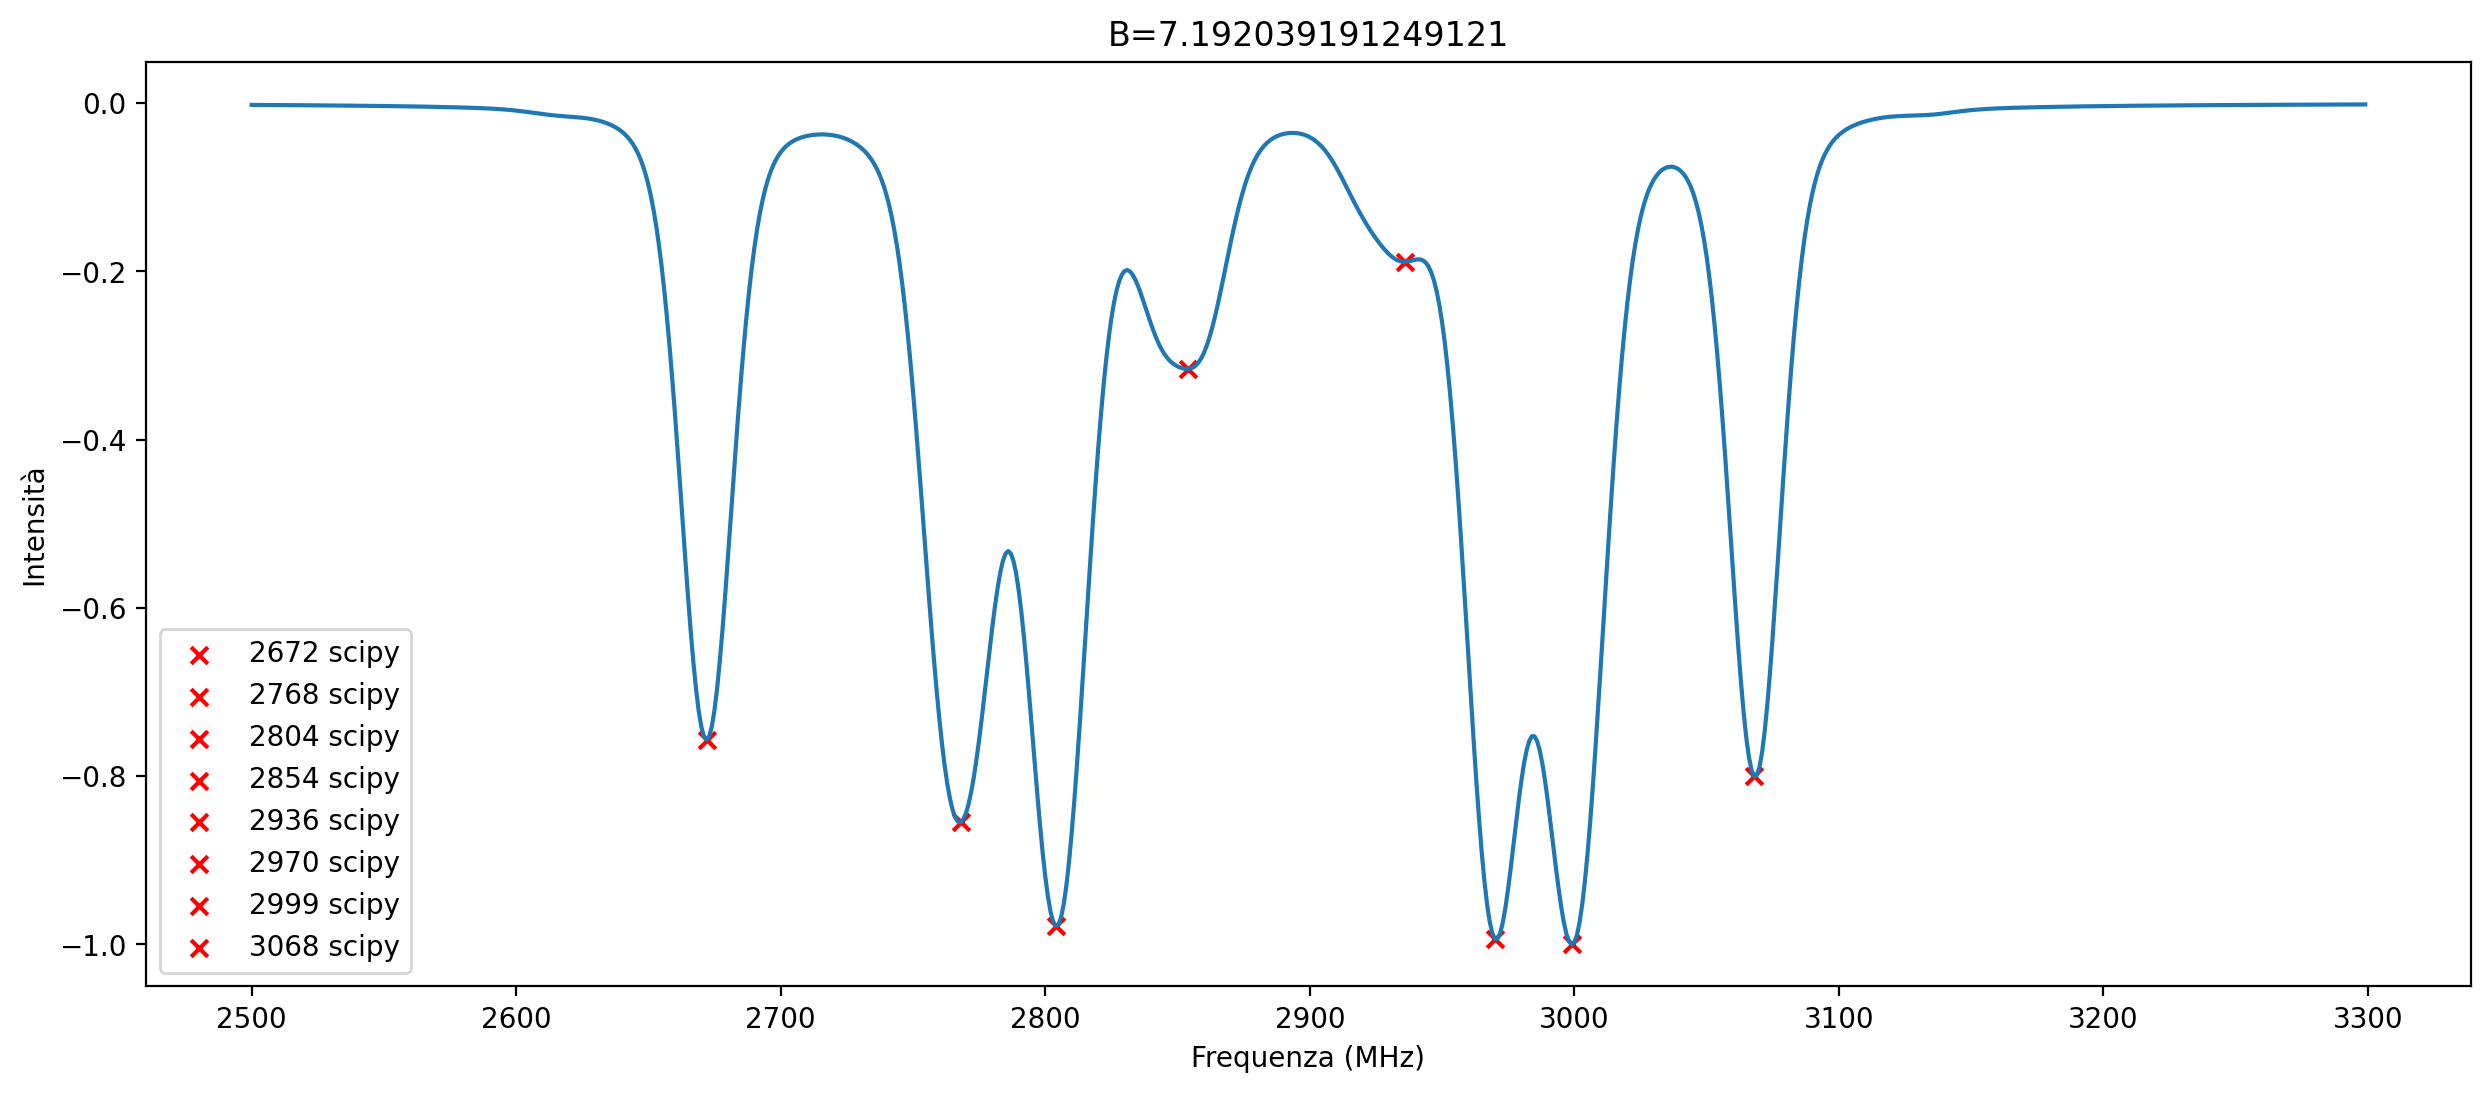

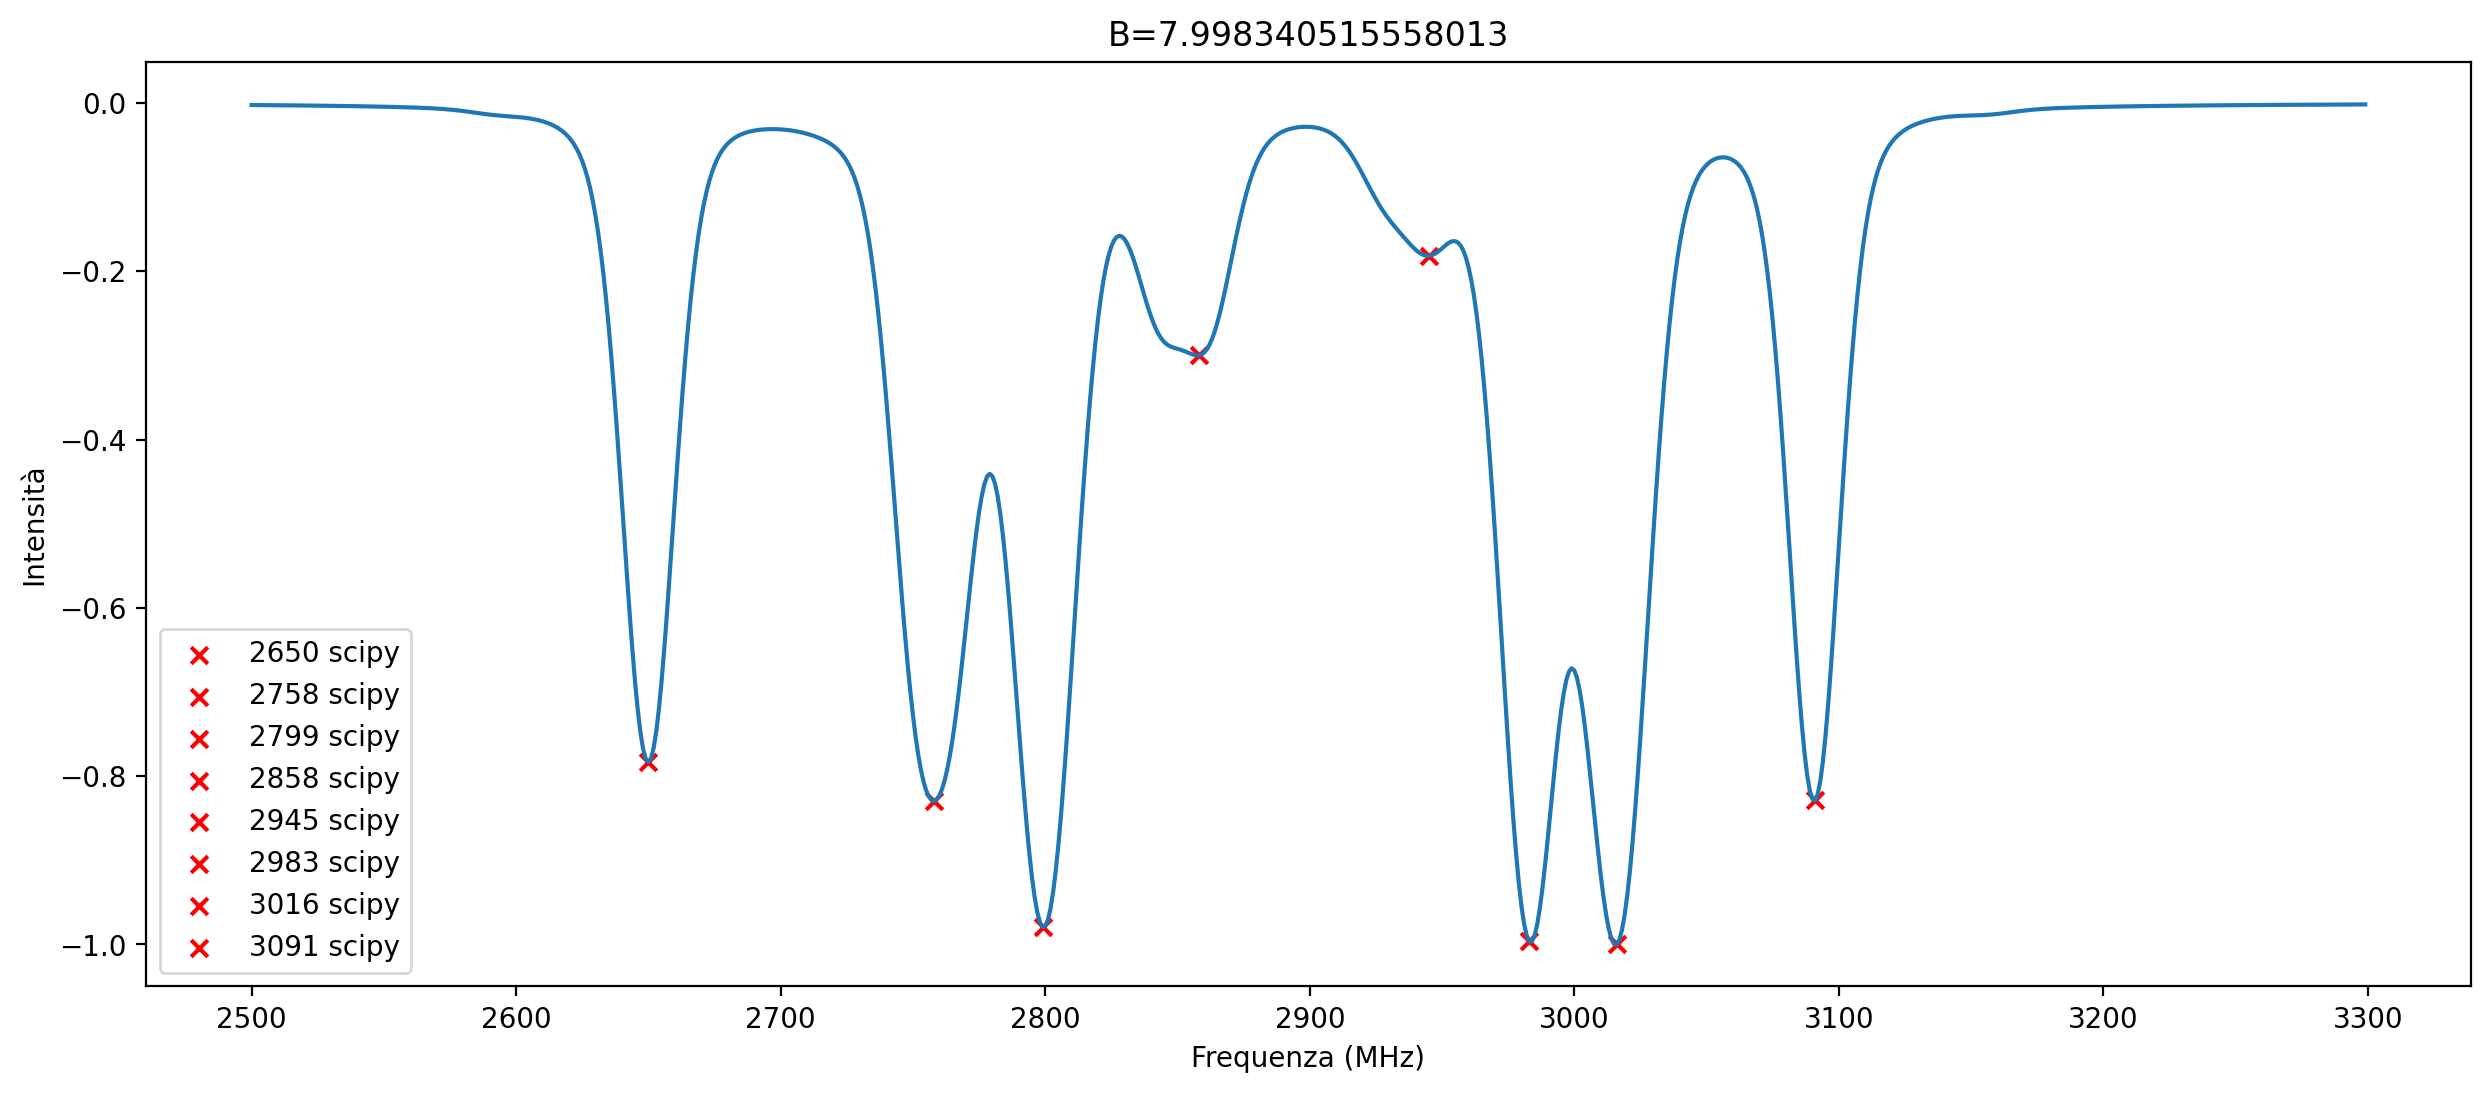

In [8]:
import matplotlib.pyplot as plt
for k in k_list:
    plt.figure(figsize=(15, 6), dpi=200)
    plt.plot(x_axis, s[k])
    for pos in posizioni_totali[k]:
        h = info_totale[k]['peak_heights'][np.where(posizioni_totali[k] == pos)[0][0]]
        plt.scatter(pos, -h, color='red', marker='x', label=f'{pos} scipy')  # Evidenziamo i picchi
    plt.title(f"B={B[k]}")
    plt.xlabel('Frequenza (MHz)')
    plt.ylabel('Intensità')
    plt.legend()
    plt.show()

provo fit

## Provo con pseudo-Voigt

combinazione lineare di lorentziana e gaussiana
$$
pV(\nu | \eta, \nu_0, \Gamma, \sigma) = \eta L(\nu | \nu_0, \Gamma) + (1-\eta) G(\nu | \nu_0, \sigma)
$$
con
$$
\begin{cases}
L(\nu | \nu_0, \Gamma) = 
\frac{\Gamma}{\pi[(\nu-\nu_0)^2 + \Gamma^2]}\\
G(\nu | \nu_0, \sigma) = 
\frac{1}{sigma\sqrt{2\pi}}e^\frac{(\nu-\nu_0)^2}{2\sigma^2}
\end{cases}
$$

In [9]:
from ml_odmr.otto_voigt import fit_otto_pseudo_voigt, otto_pseudo_voigt

ampiezze_fit, posizioni_fit, gamma_fit, sigma_fit, eta_fit, y0_fit = {}, {}, {}, {}, {}, {}

In [10]:
for k in k_list:
    ampiezze_fit[k], posizioni_fit[k], gamma_fit[k], sigma_fit[k], eta_fit[k], y0_fit[k] = fit_otto_pseudo_voigt(
        f,
        s[k],
        info_totale[k]['peak_heights'],
        posizioni_totali[k],
        info_totale[k]['widths'],
        info_totale[k]['widths']*0.5,  # Stima iniziale per sigma (gaussiana) come metà di gamma (lorentziana)
        np.full_like(info_totale[k]['widths'], 0.5)  # Stima iniziale per eta (mix tra gaussiana e lorentziana) a 0.5
    )

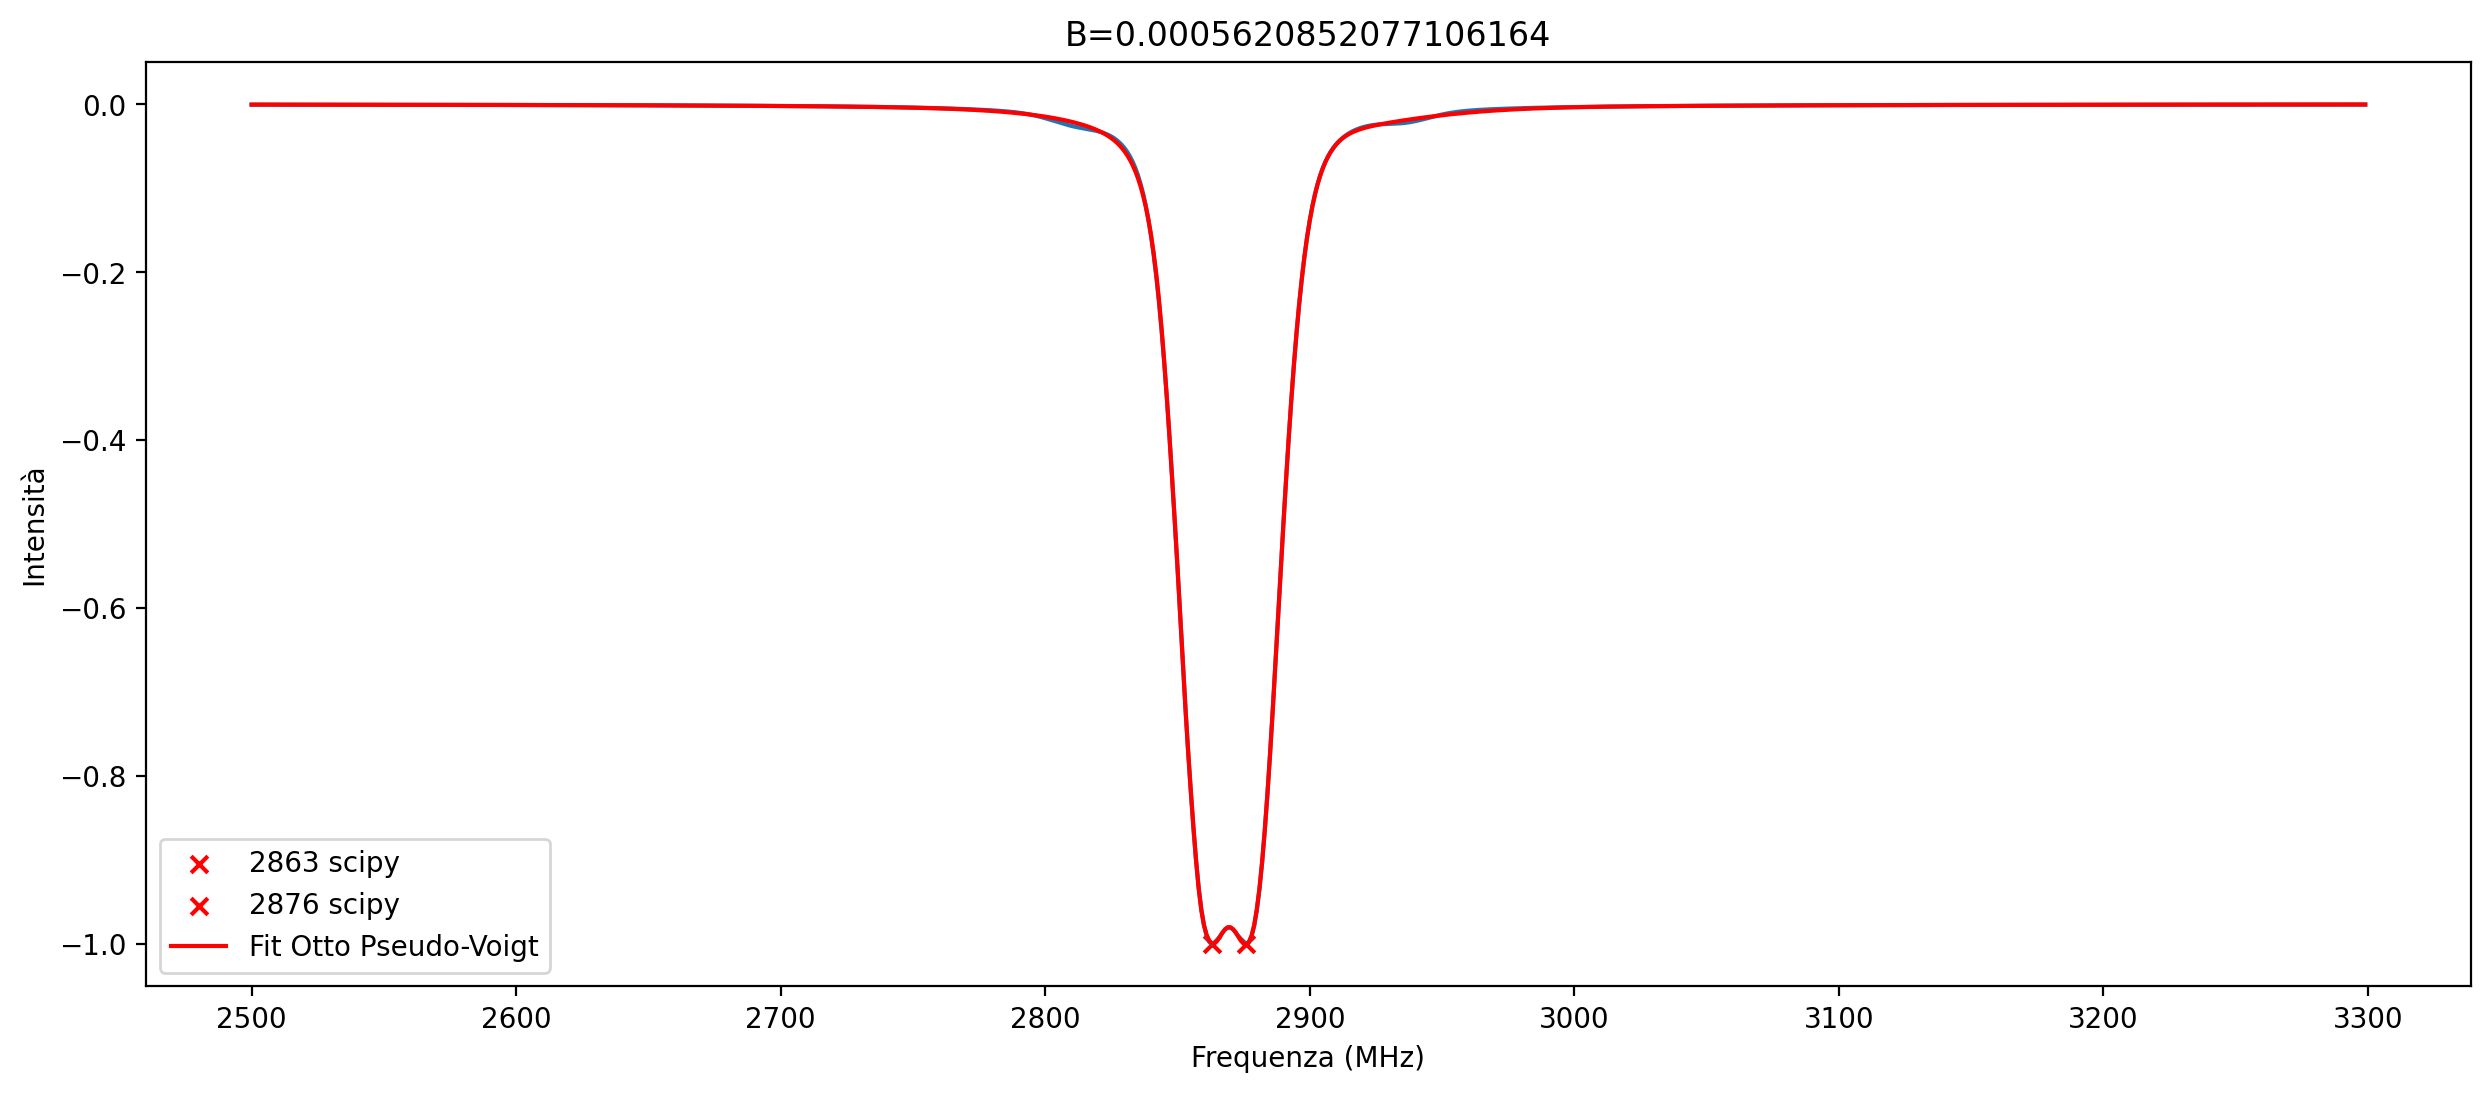

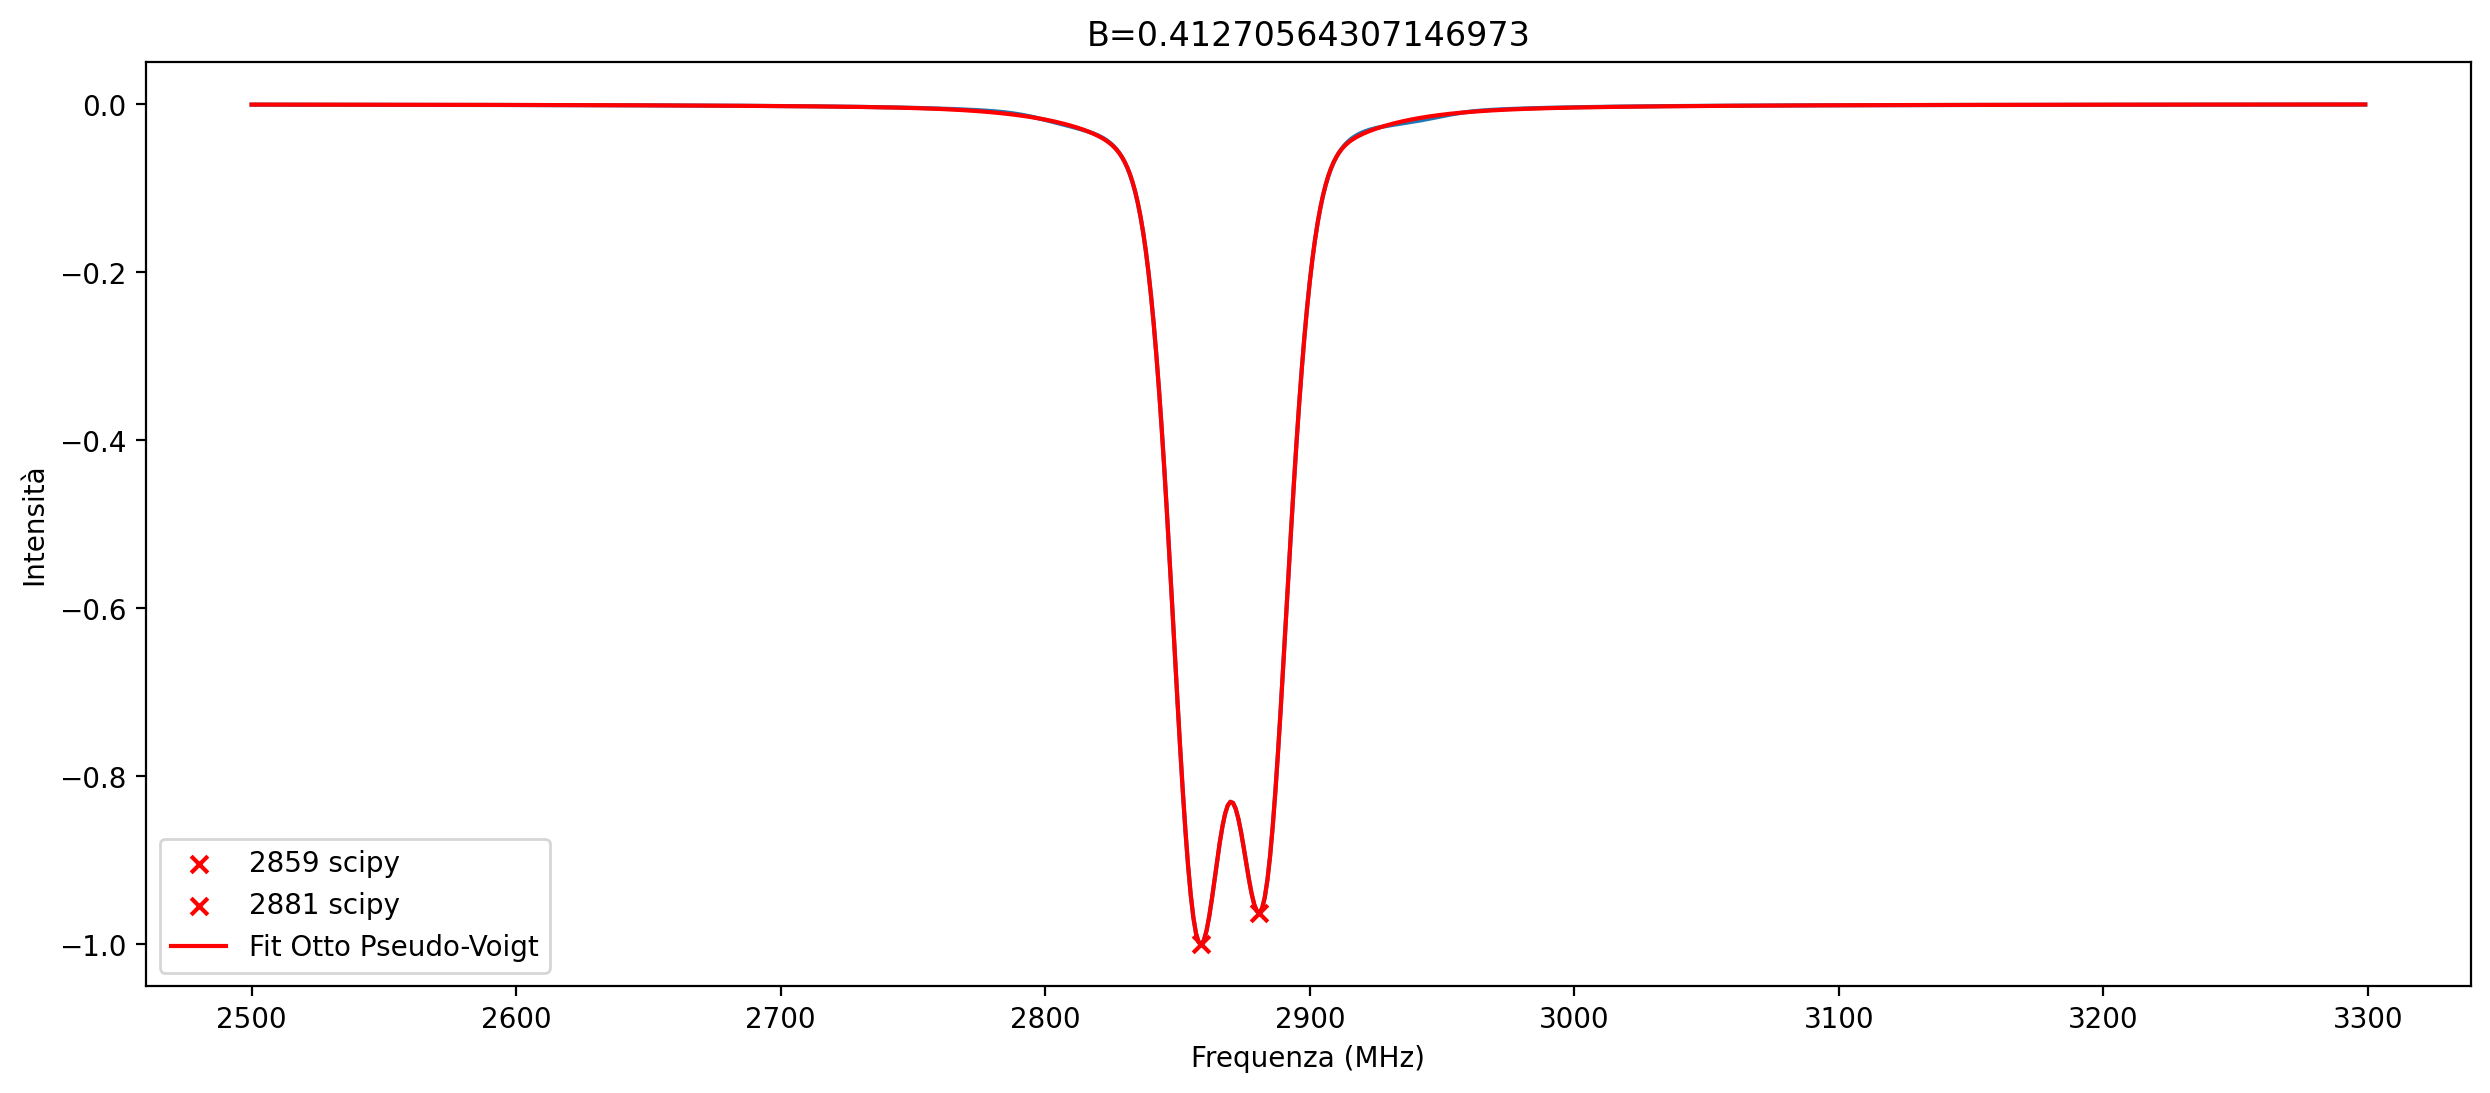

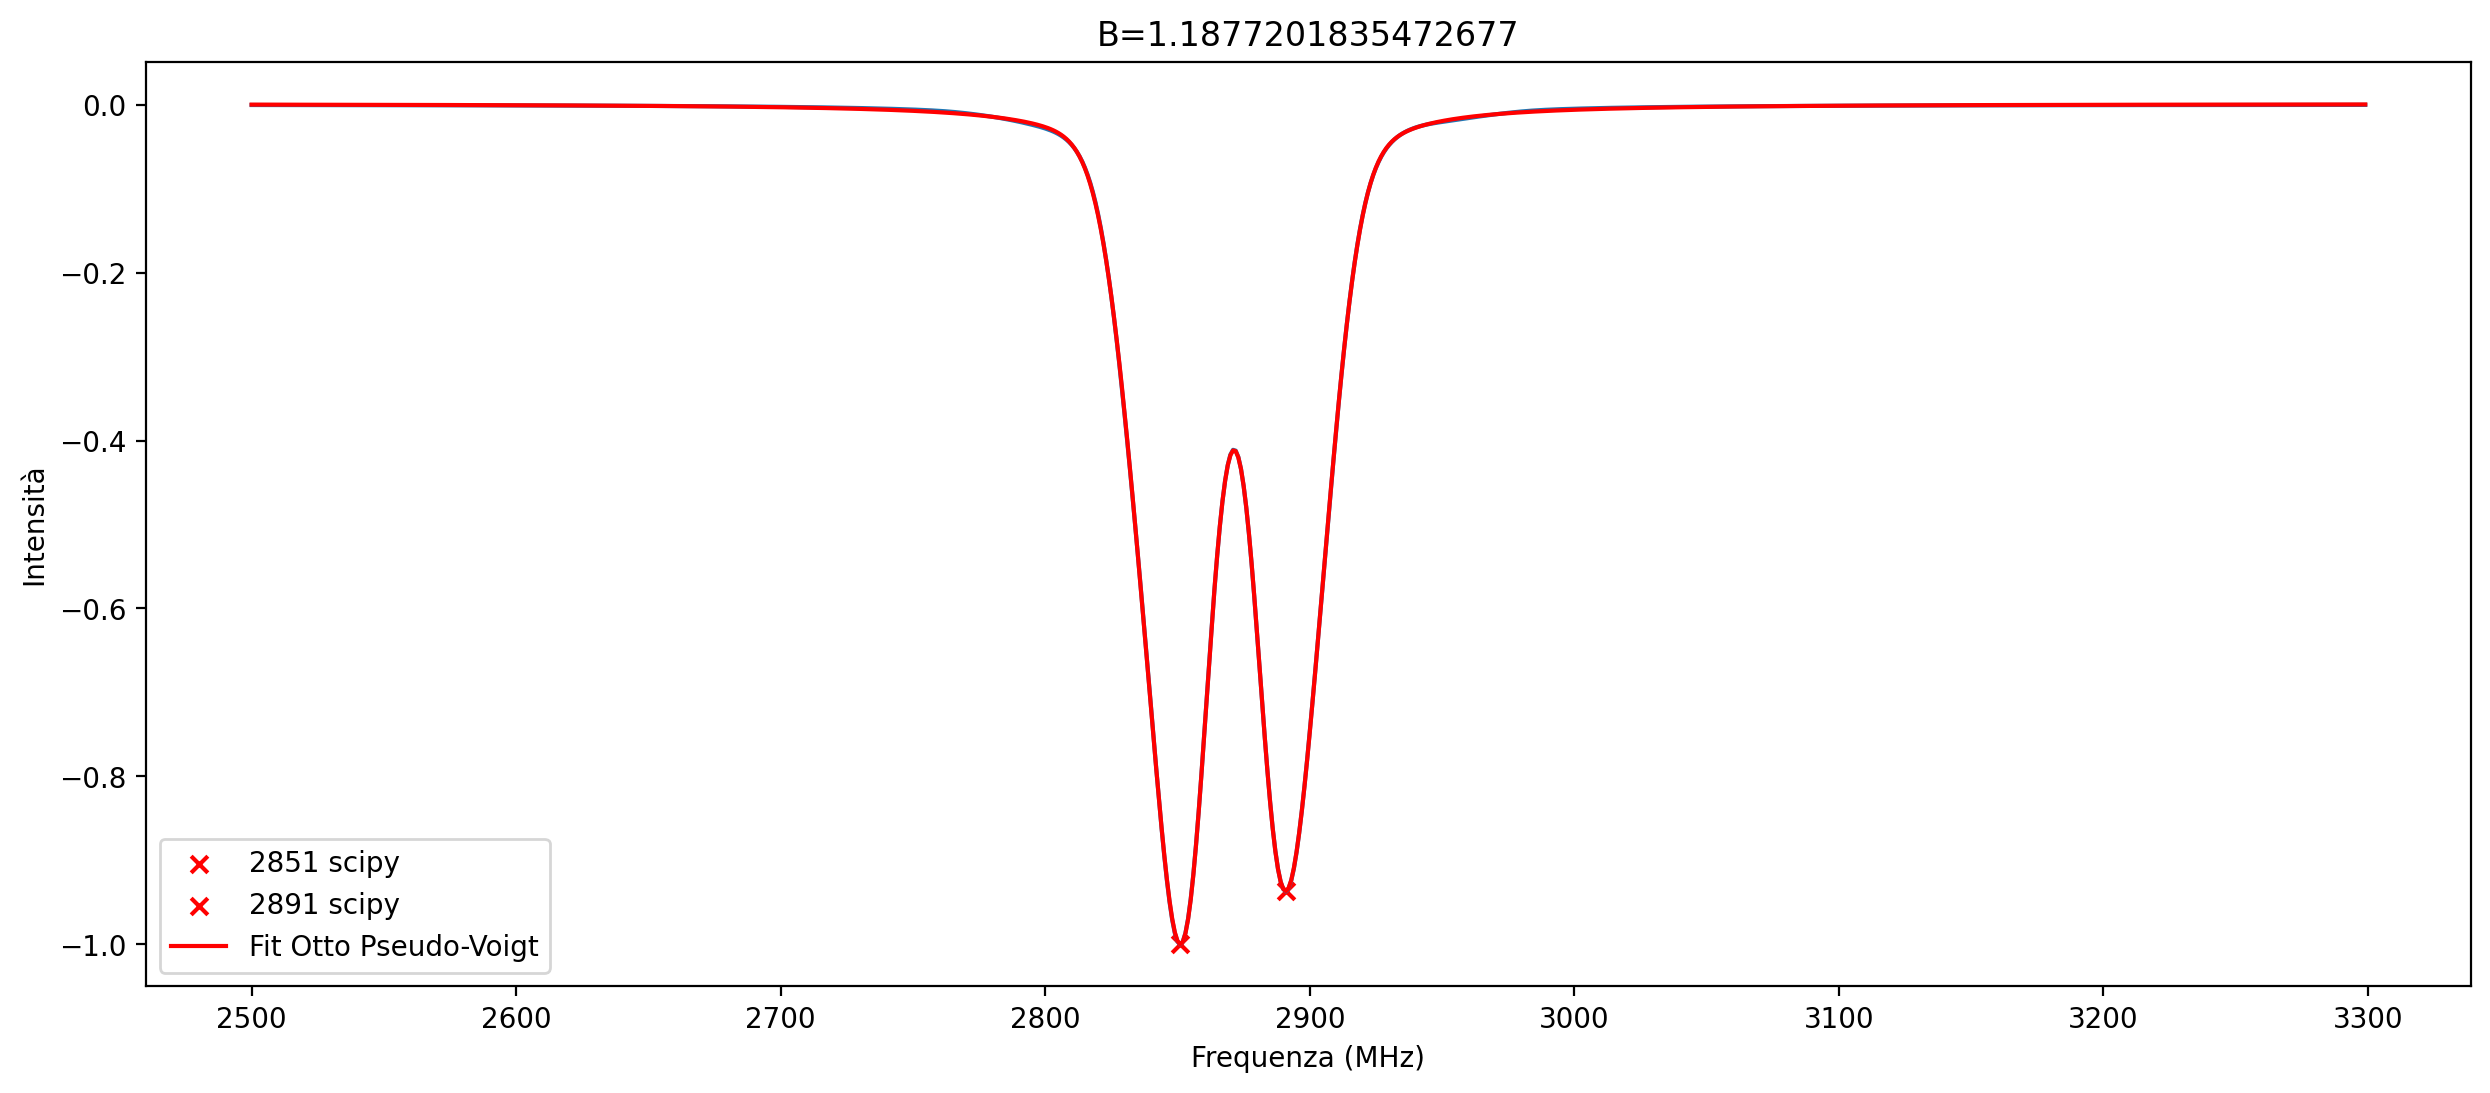

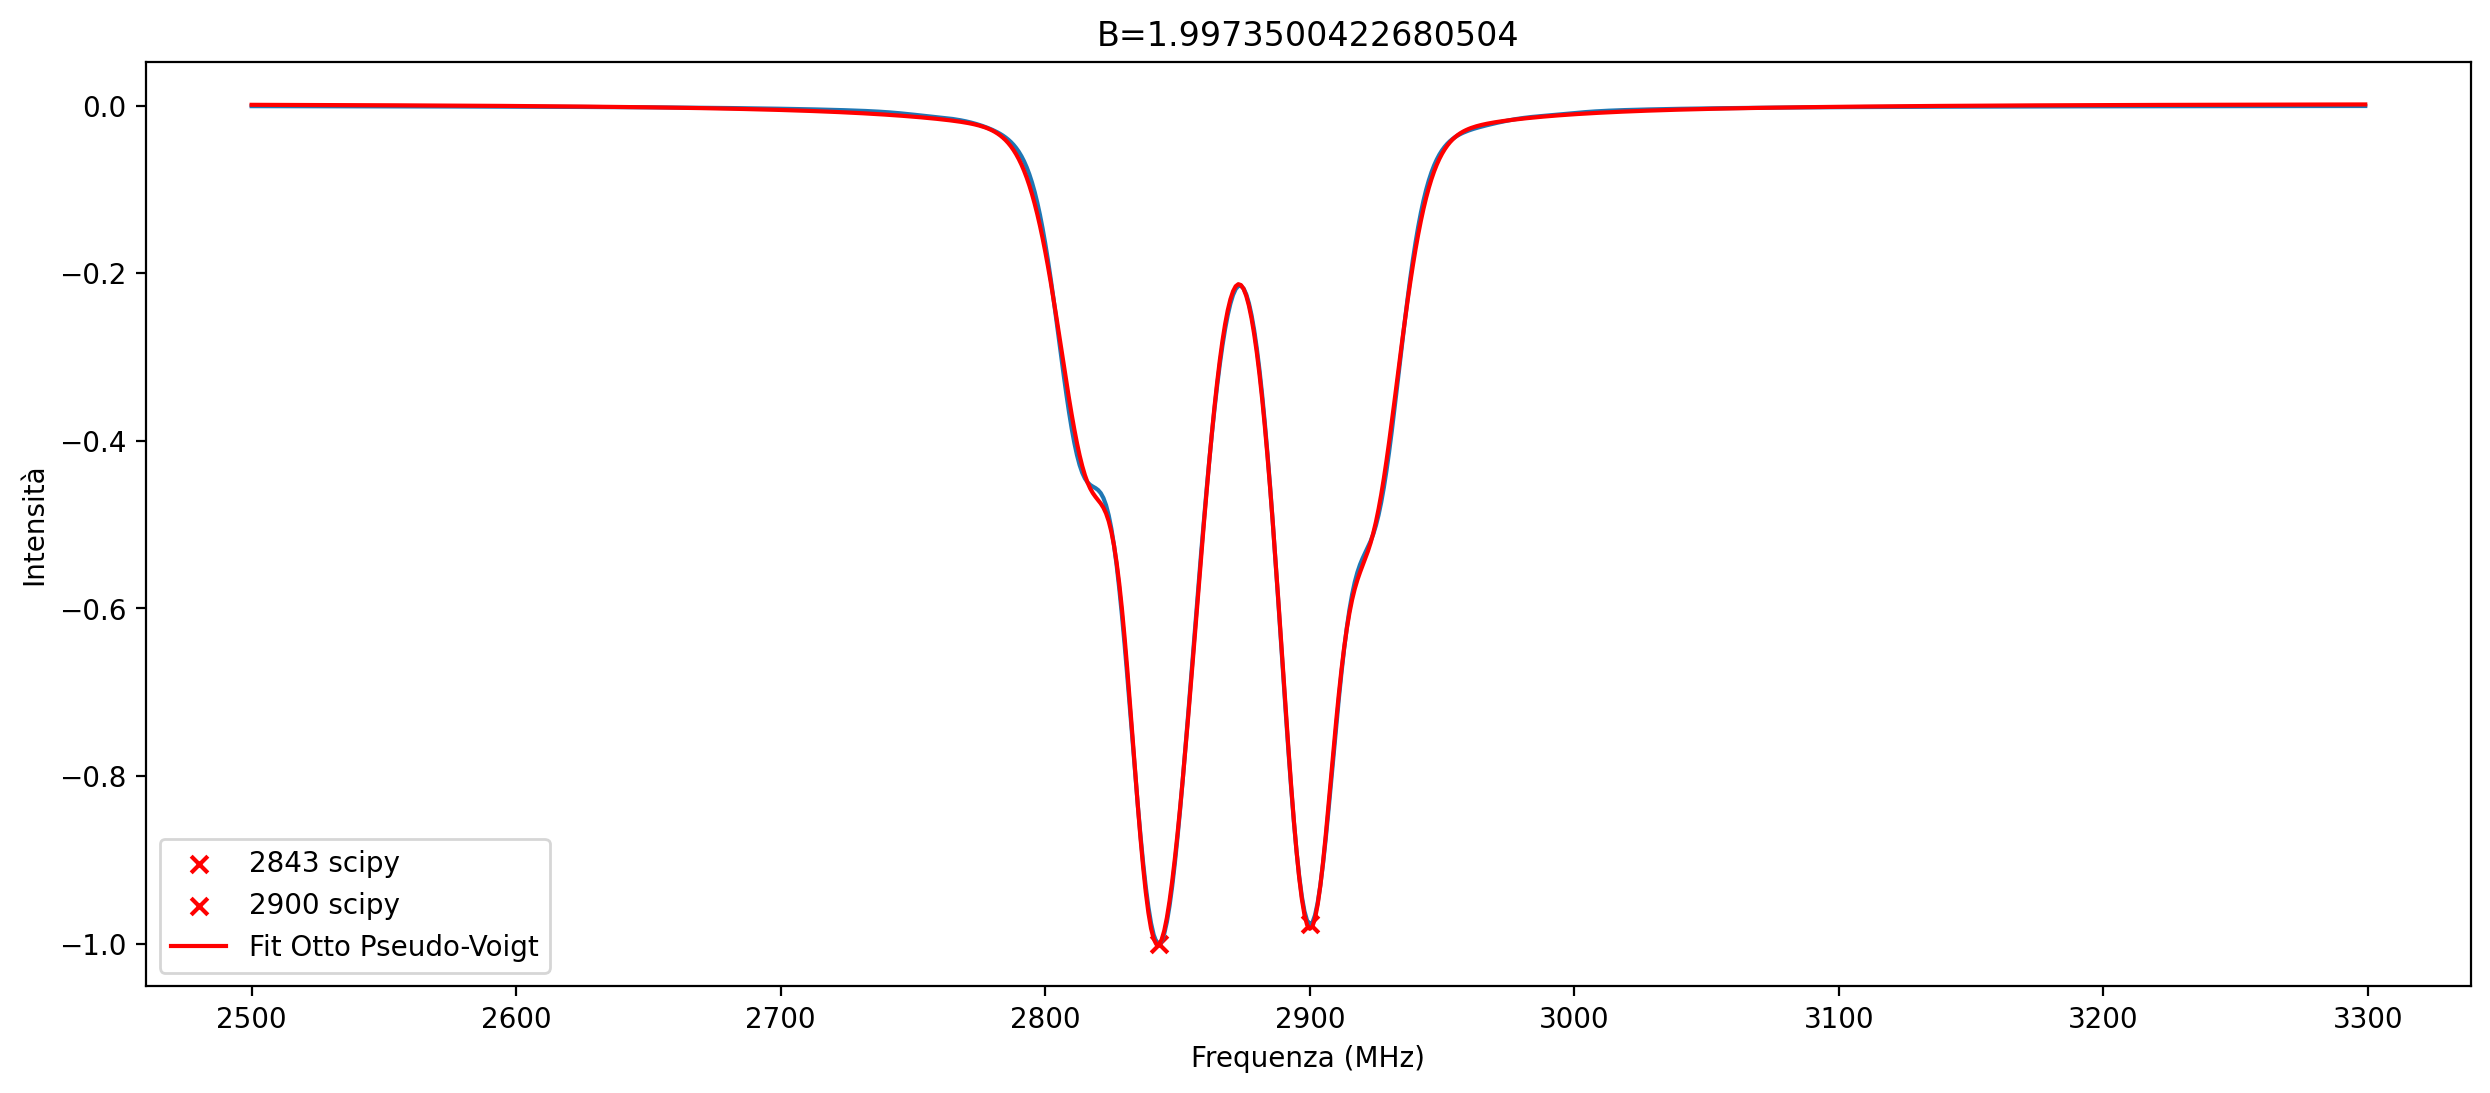

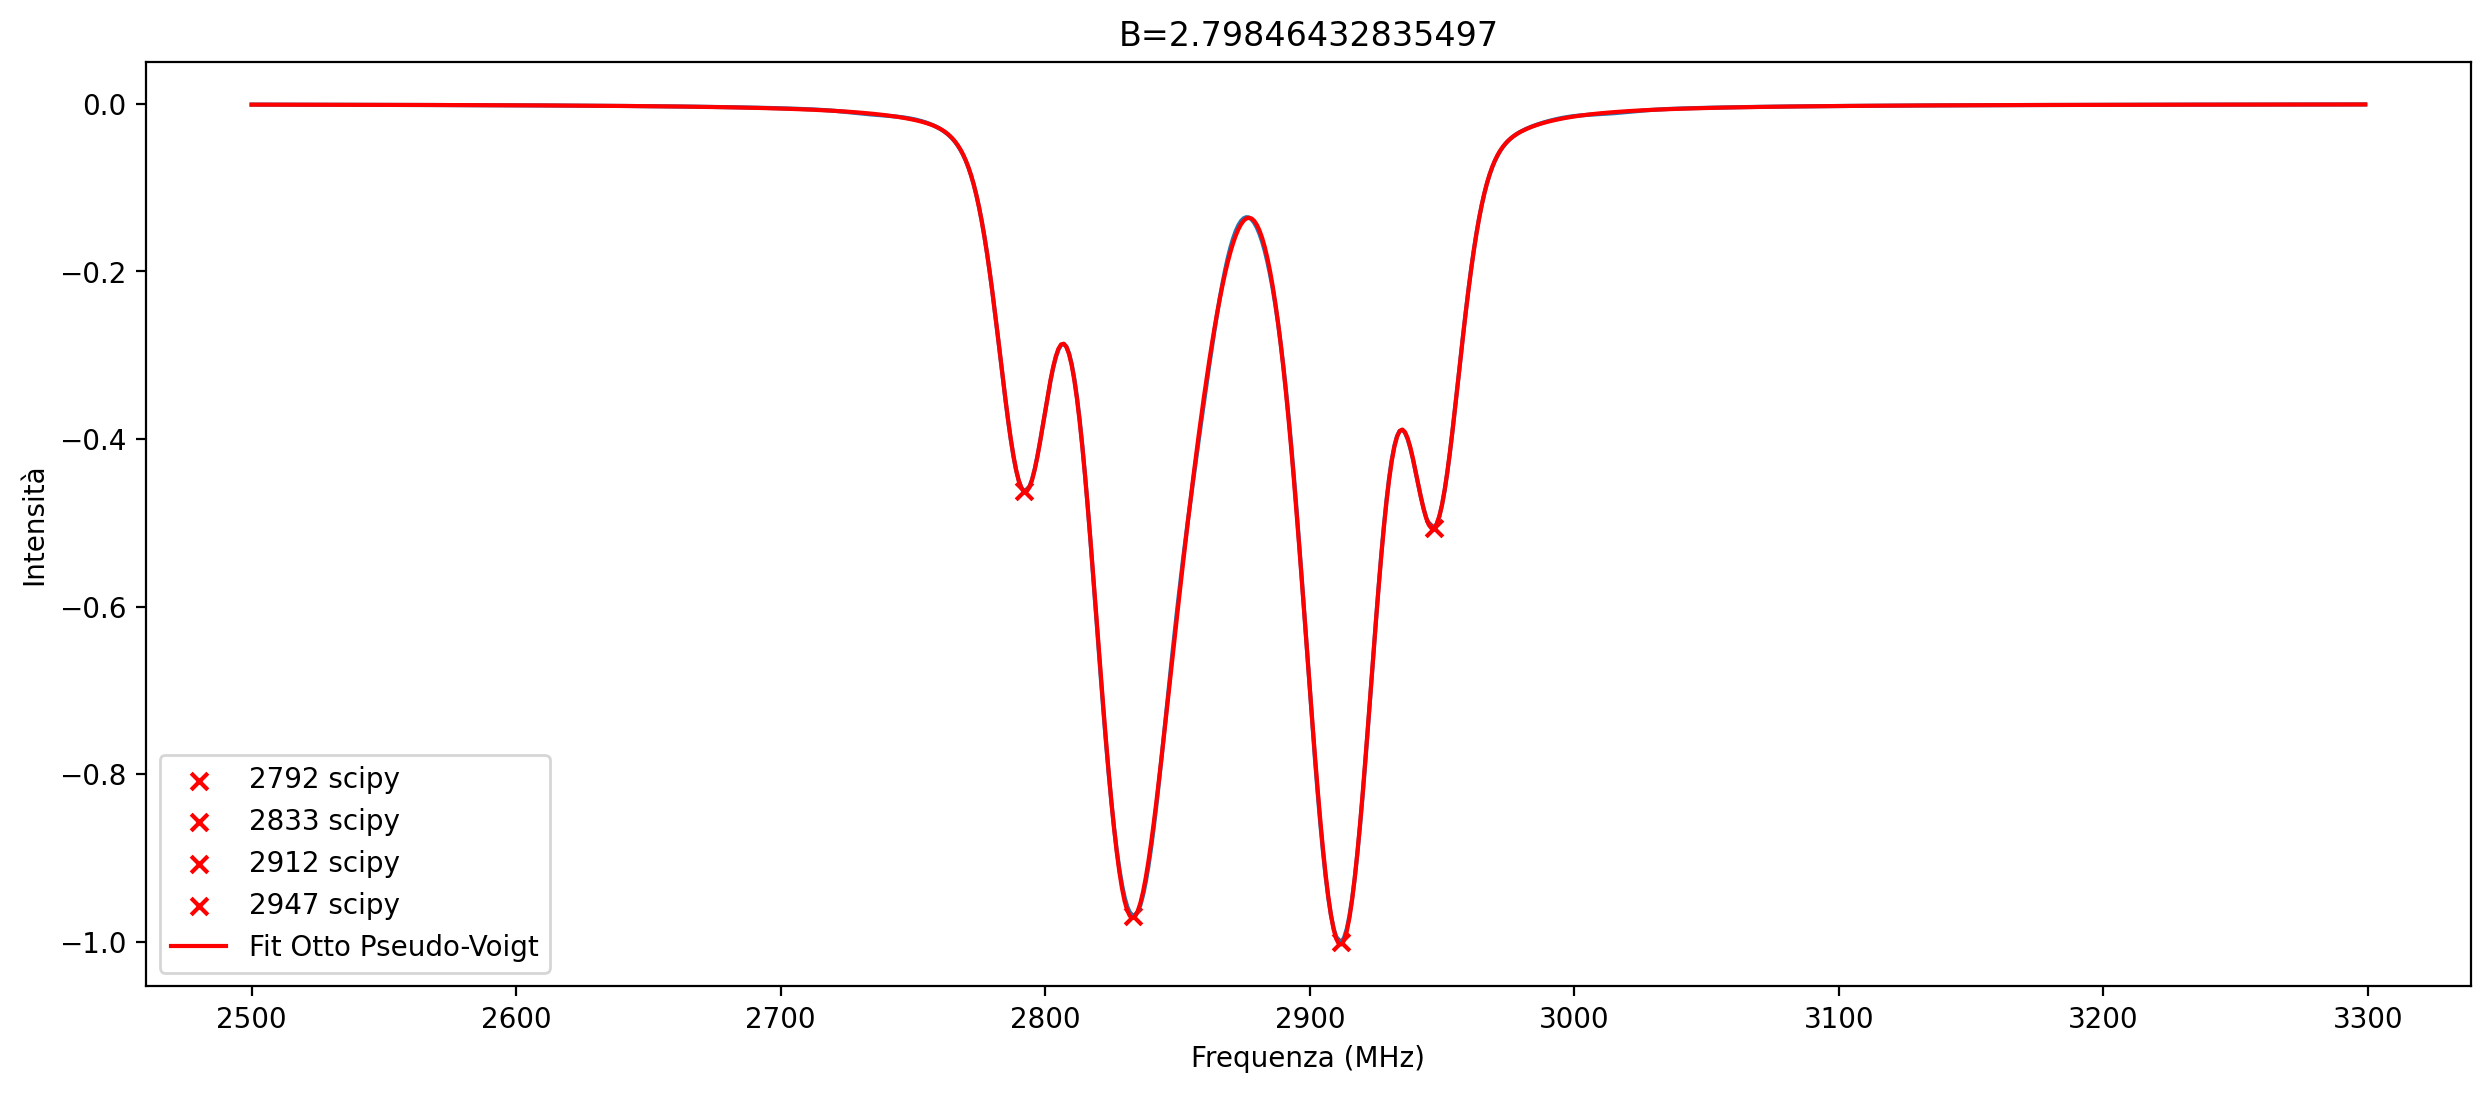

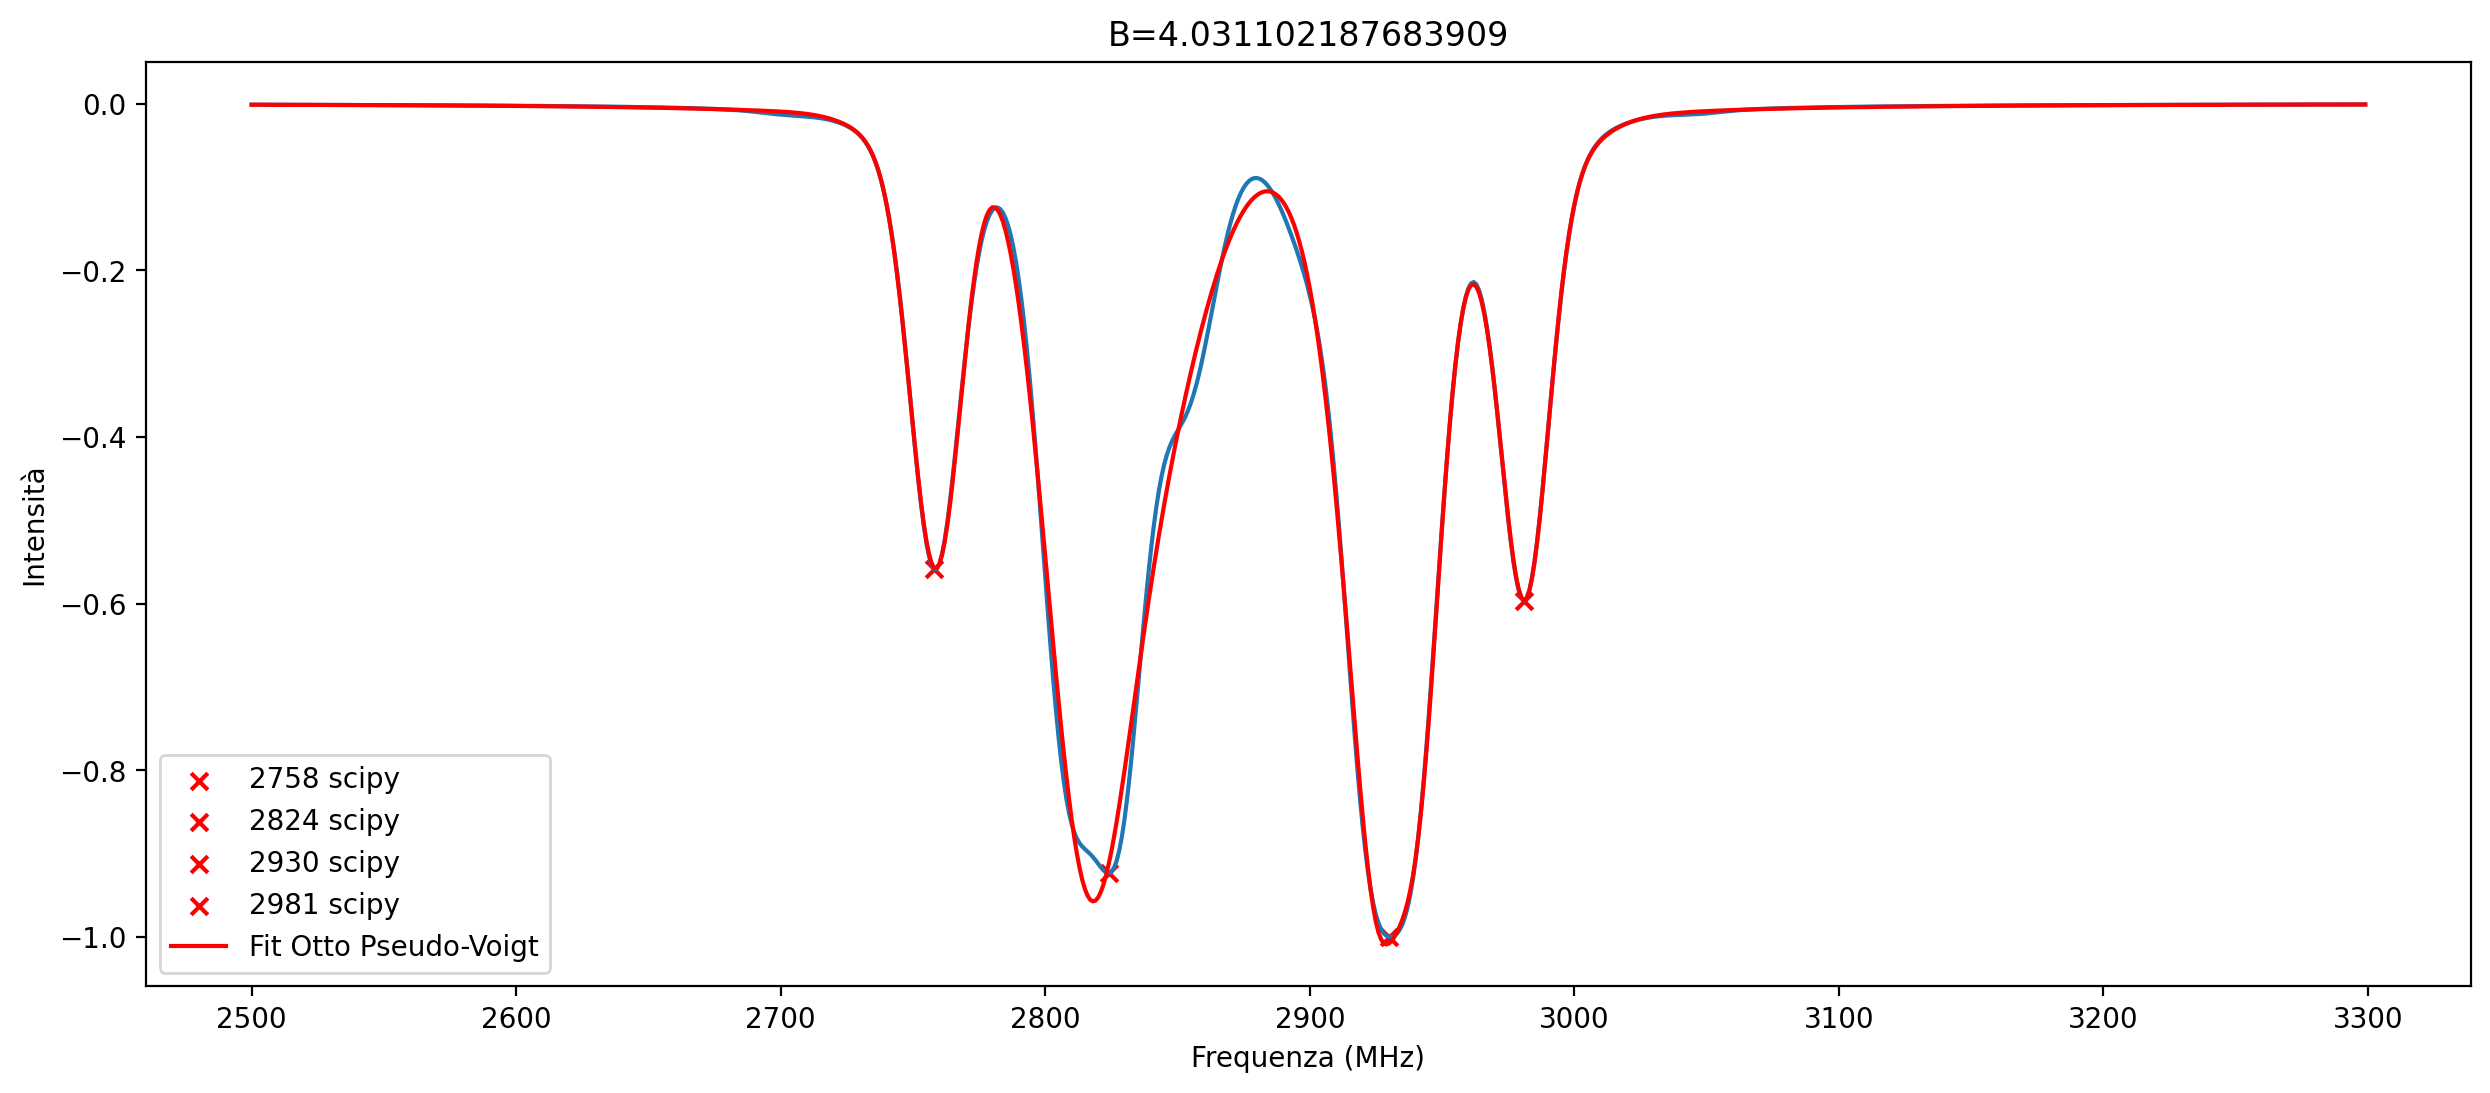

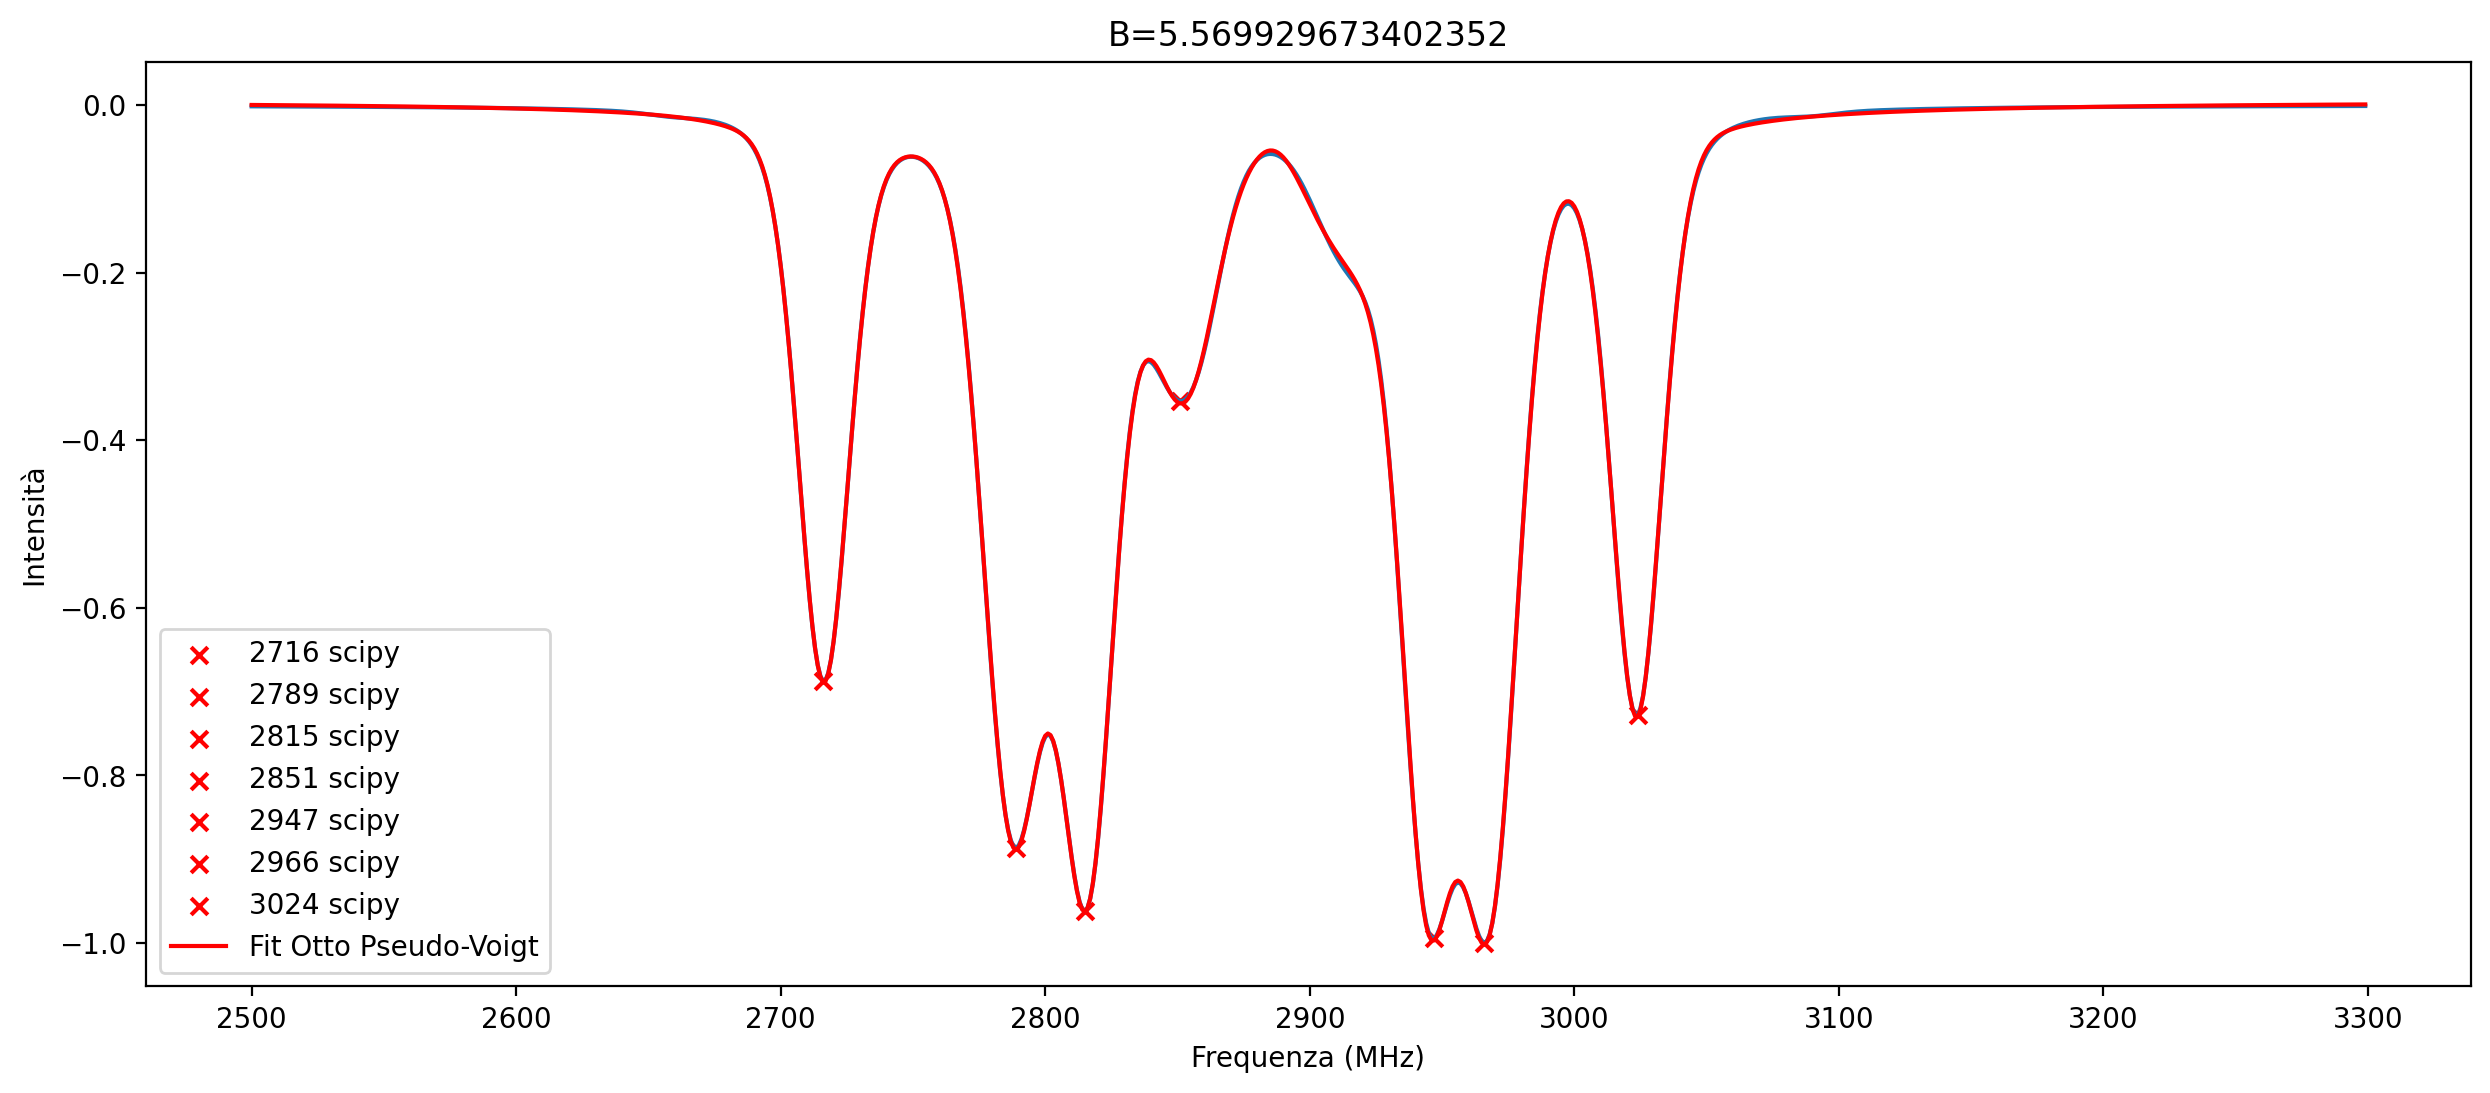

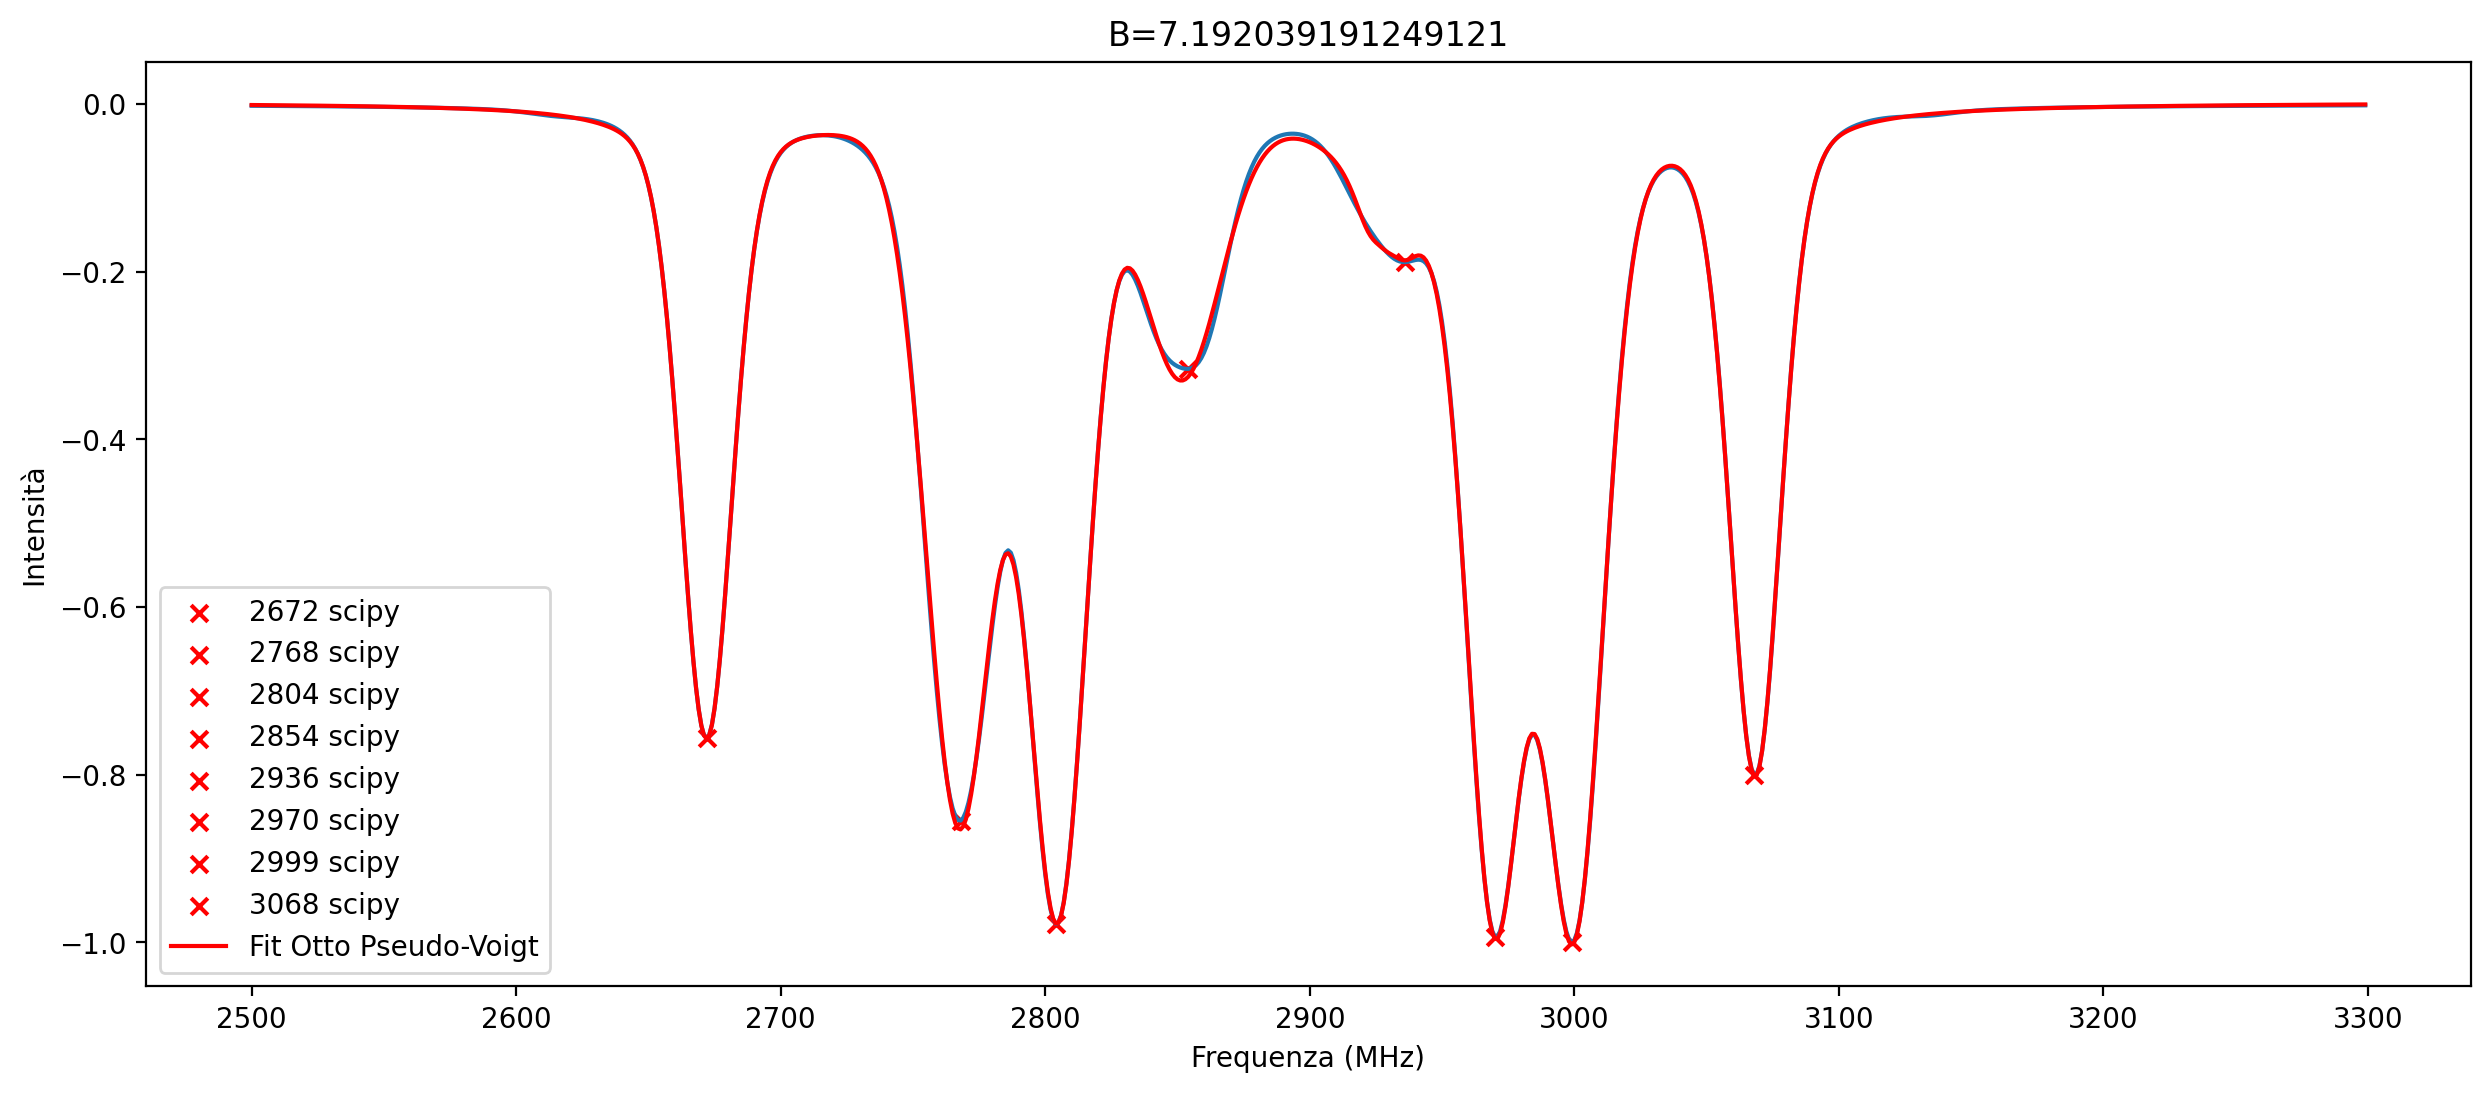

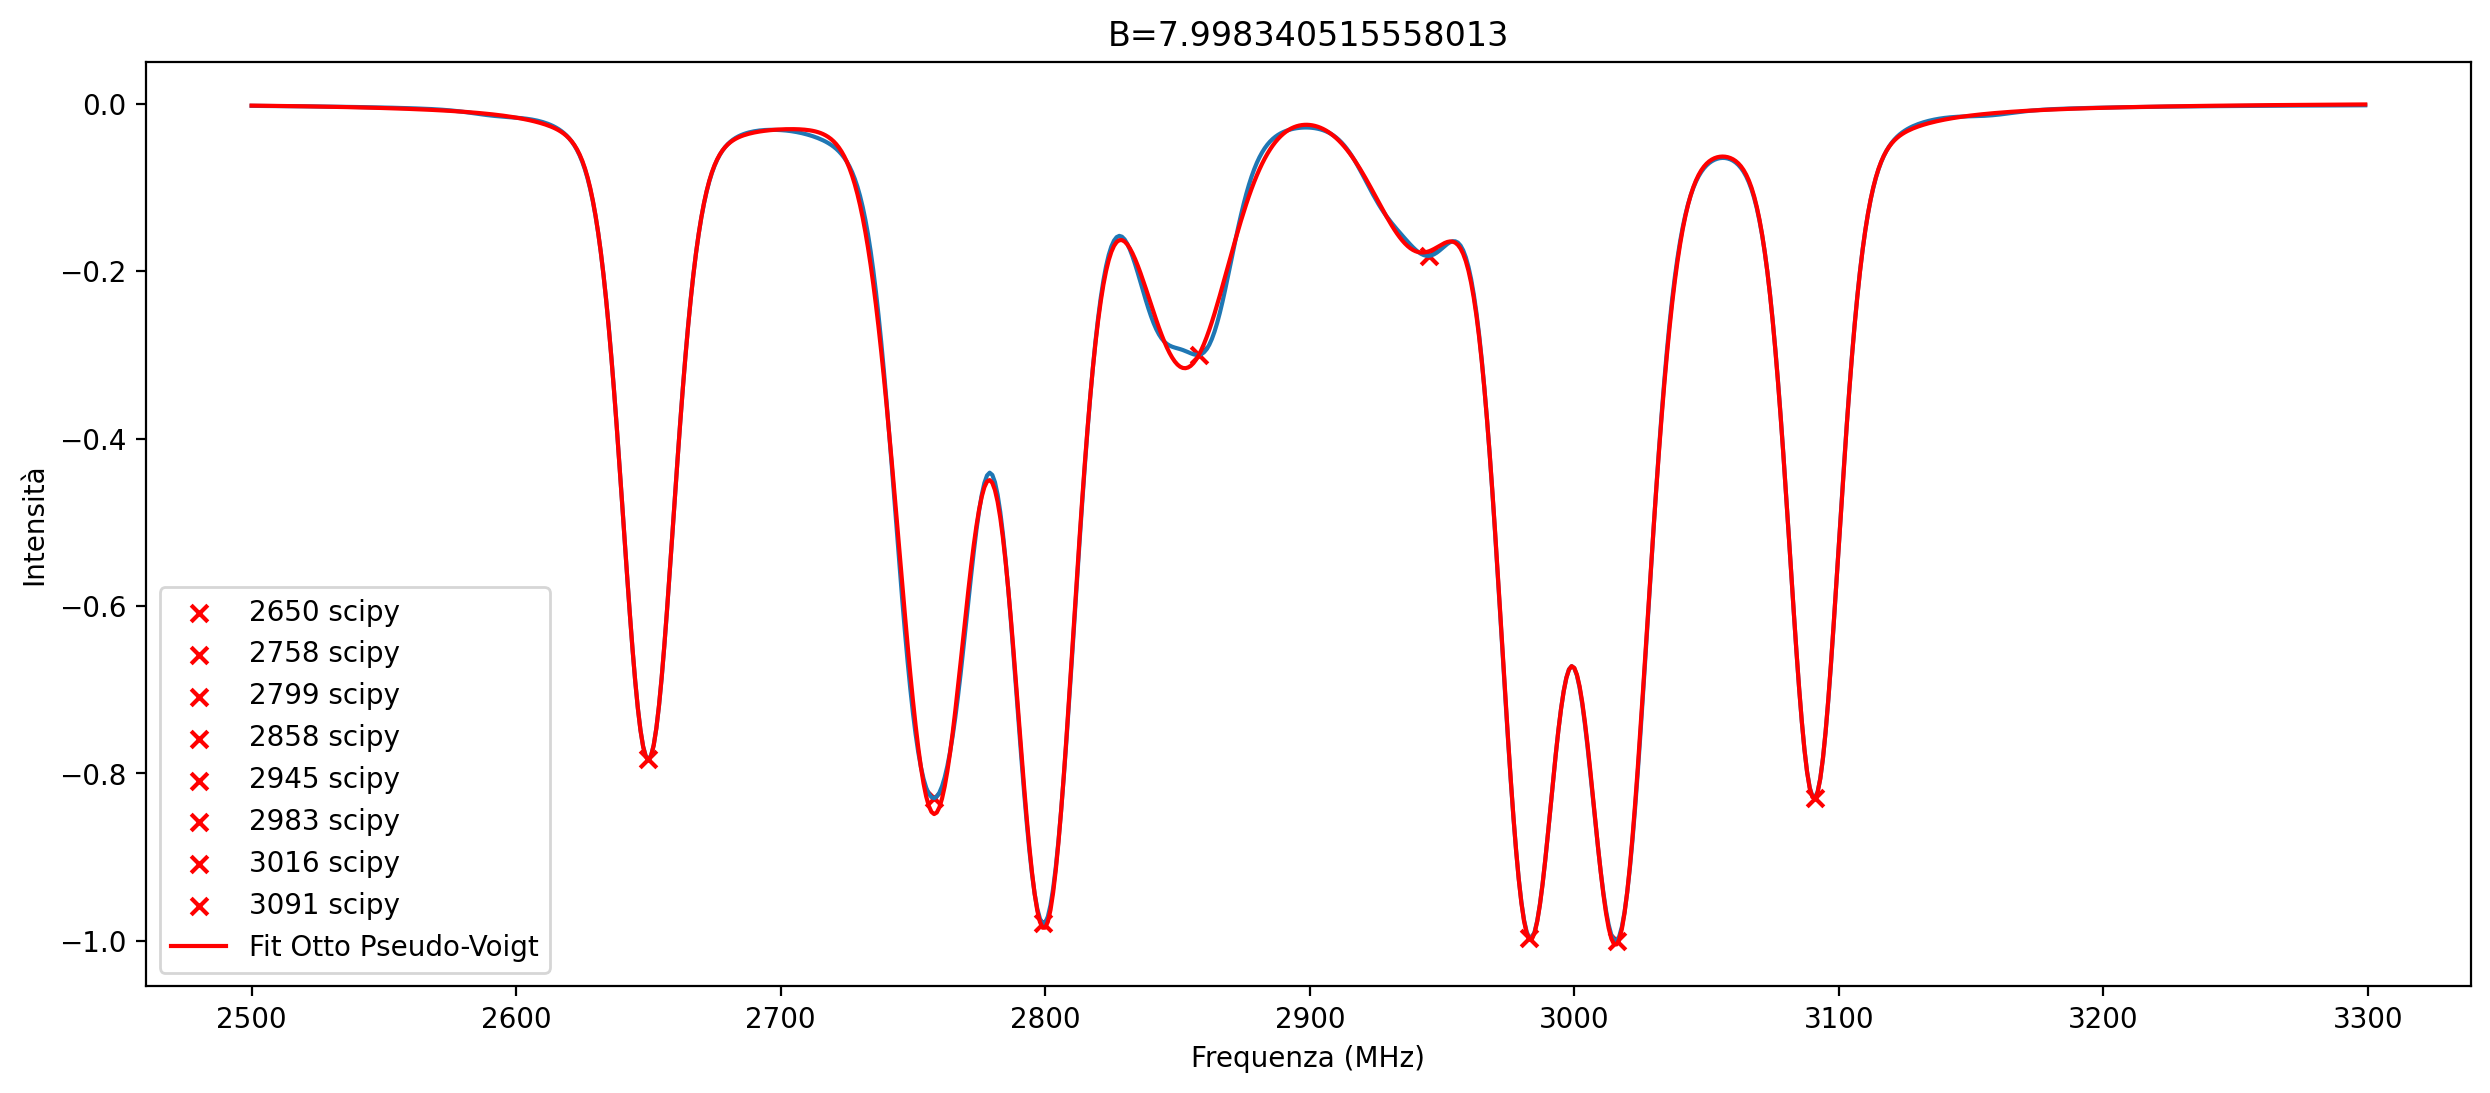

In [11]:
for k in k_list:    
    plt.figure(figsize=(15, 6), dpi=200)
    plt.plot(x_axis, s[k])
    for pos in posizioni_totali[k]:
        h = info_totale[k]['peak_heights'][np.where(posizioni_totali[k] == pos)[0][0]]
        plt.scatter(pos, -h, color='red', marker='x', label=f'{pos} scipy')  # Evidenziamo i picchi
    plt.plot(f, -otto_pseudo_voigt(f, ampiezze_fit[k], posizioni_fit[k], gamma_fit[k], sigma_fit[k], eta_fit[k], y0_fit[k]), color='red', label='Fit Otto Pseudo-Voigt')  # Plot del fit
    plt.title(f"B={B[k]}")
    plt.xlabel('Frequenza (MHz)')
    plt.ylabel('Intensità')
    plt.legend()
plt.show()

In [12]:
for i in range(8): print(f"{posizioni_fit[0][i]:.1f}")

2853.0
2875.3
2862.6
2868.1
2860.7
2882.0
2857.7
2880.8


In [13]:
for i in range(8): print(f"{posizioni_fit[-1][i]:.1f}")

2649.9
2757.9
2799.7
2853.2
2941.6
2982.9
3015.9
3090.7


In [14]:
(np.max(posizioni_totali[k]) + np.min(posizioni_totali[k])) / 2

2870.5